# 01 — Explorative Datenanalyse (EDA)

**Scope:** Daten laden, bereinigen, Churn-Verteilung, Churn nach Segmenten, Korrelationen, Tenure-Tiefenanalyse.

Alle Plots werden in `plots/` als PNG (300 DPI) exportiert.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from src.data_prep import load_raw_data, clean_data

# --- Plot-Stil (einheitlich fuer alle Notebooks) ---
sns.set_theme(style="whitegrid", font_scale=1.2)
CHURN_COLORS = {"Yes": "#e74c3c", "No": "#3498db"}
CHURN_COLORS_01 = {1: "#e74c3c", 0: "#3498db"}
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)

ModuleNotFoundError: No module named 'seaborn'

---
## 1. Daten laden & bereinigen

### 1.1 Laden und erster Ueberblick

In [ ]:
df_raw = load_raw_data()

print(f"Shape: {df_raw.shape}")
print(f"\nDatentypen:\n{df_raw.dtypes}")
df_raw.head()

Shape: (7043, 21)

Datentypen:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 1.2 Datenbereinigung

In [ ]:
# TotalCharges: Leere Strings identifizieren
empty_tc = df_raw[df_raw["TotalCharges"] == " "]
print(f"Leere TotalCharges: {len(empty_tc)} Eintraege")
print(f"Alle haben tenure=0: {(empty_tc['tenure'] == 0).all()}")
empty_tc[["customerID", "tenure", "TotalCharges", "MonthlyCharges"]]

Leere TotalCharges: 11 Eintraege
Alle haben tenure=0: True


,customerID,tenure,TotalCharges,MonthlyCharges
488,4472-LVYGI,0,,52.55
753,3115-CZMZD,0,,20.25
936,5709-LVOEQ,0,,80.85
1082,4367-NUYAO,0,,25.75
1340,1371-DWPAZ,0,,56.05
3331,7644-OMVMY,0,,19.85
3826,3213-VVOLG,0,,25.35
4380,2520-SGTTA,0,,20.00
5218,2923-ARZLG,0,,19.70
6670,4075-WKNIU,0,,73.35


In [ ]:
df = clean_data(df_raw)

print(f"Shape nach Bereinigung: {df.shape}")
print(f"\nFehlende Werte:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
if df.isnull().sum().sum() == 0:
    print("Keine fehlenden Werte vorhanden.")

print(f"\nTotalCharges Typ: {df['TotalCharges'].dtype}")
print(f"Churn-Werte: {df['Churn'].unique()}")

Shape nach Bereinigung: (7043, 20)

Fehlende Werte:
Series([], dtype: int64)
Keine fehlenden Werte vorhanden.

TotalCharges Typ: float64
Churn-Werte: [0 1]


### 1.3 Zielvariable

In [ ]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Churn-Verteilung:")
print(f"  Kein Churn (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"  Churn     (1):  {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")

Churn-Verteilung:
  Kein Churn (0): 5,174 (73.5%)
  Churn     (1):  1,869 (26.5%)


---
## 2. Explorative Datenanalyse

### 2.1 Churn-Verteilung

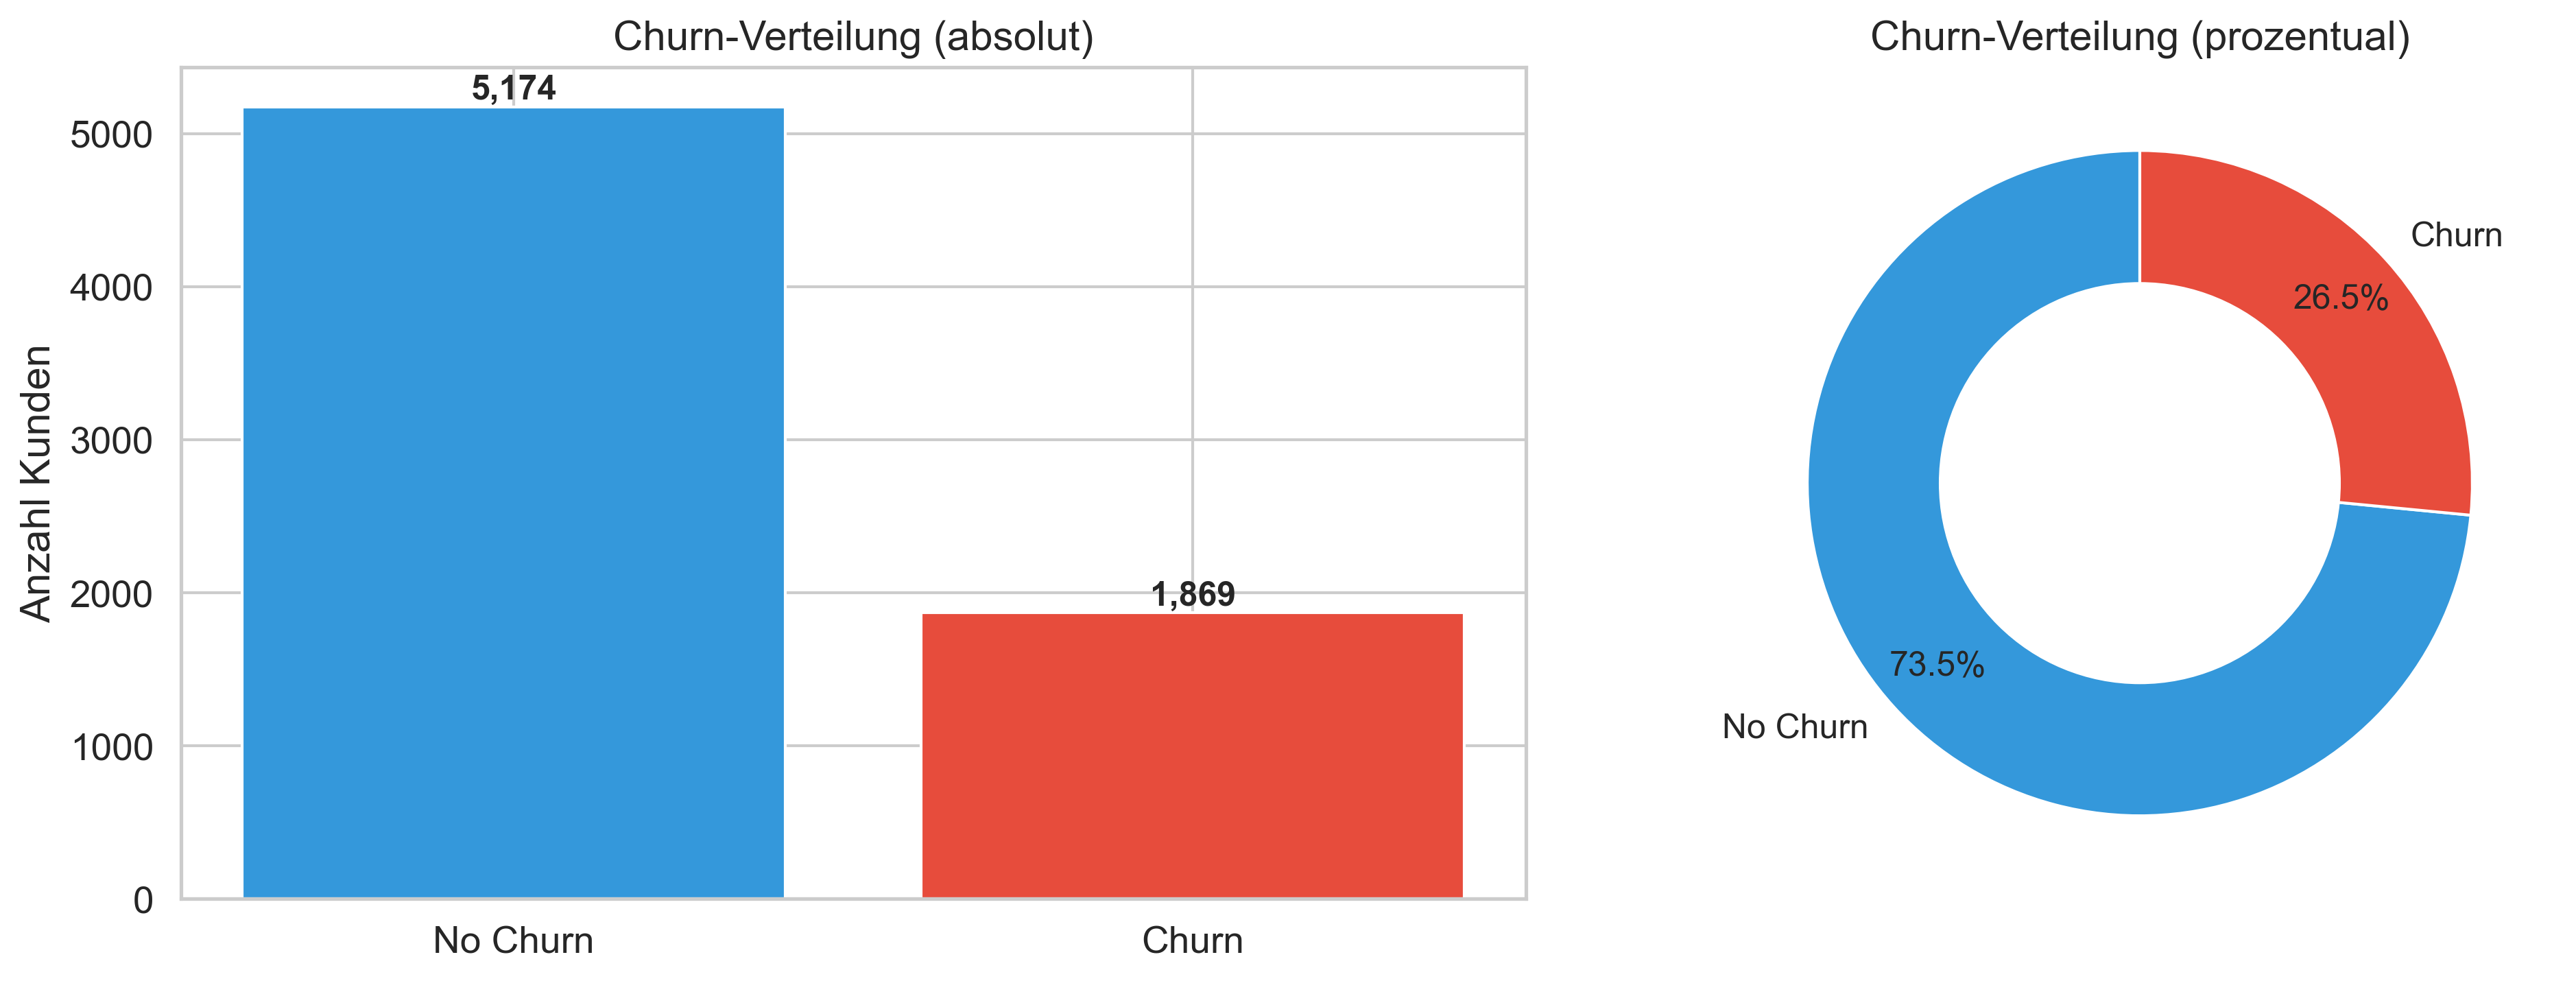

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm
bars = axes[0].bar(
    ["No Churn", "Churn"], churn_counts.values,
    color=[CHURN_COLORS_01[0], CHURN_COLORS_01[1]],
)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
        f"{val:,}", ha="center", fontsize=12, fontweight="bold",
    )
axes[0].set_ylabel("Anzahl Kunden")
axes[0].set_title("Churn-Verteilung (absolut)")

# Donut-Diagramm
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    colors=[CHURN_COLORS_01[0], CHURN_COLORS_01[1]],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    textprops={"fontsize": 12},
)
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
axes[1].add_artist(centre_circle)
axes[1].set_title("Churn-Verteilung (prozentual)")

plt.tight_layout()
fig.savefig("plots/01_churn_verteilung.png")
plt.show()

### 2.2 Churn nach Segmenten (3 Kern-Charts)

In [ ]:
# Hilfsfunktion: Churn-Rate pro Kategorie
def churn_rate_by(df, col):
    return df.groupby(col)["Churn"].mean().sort_values(ascending=False)

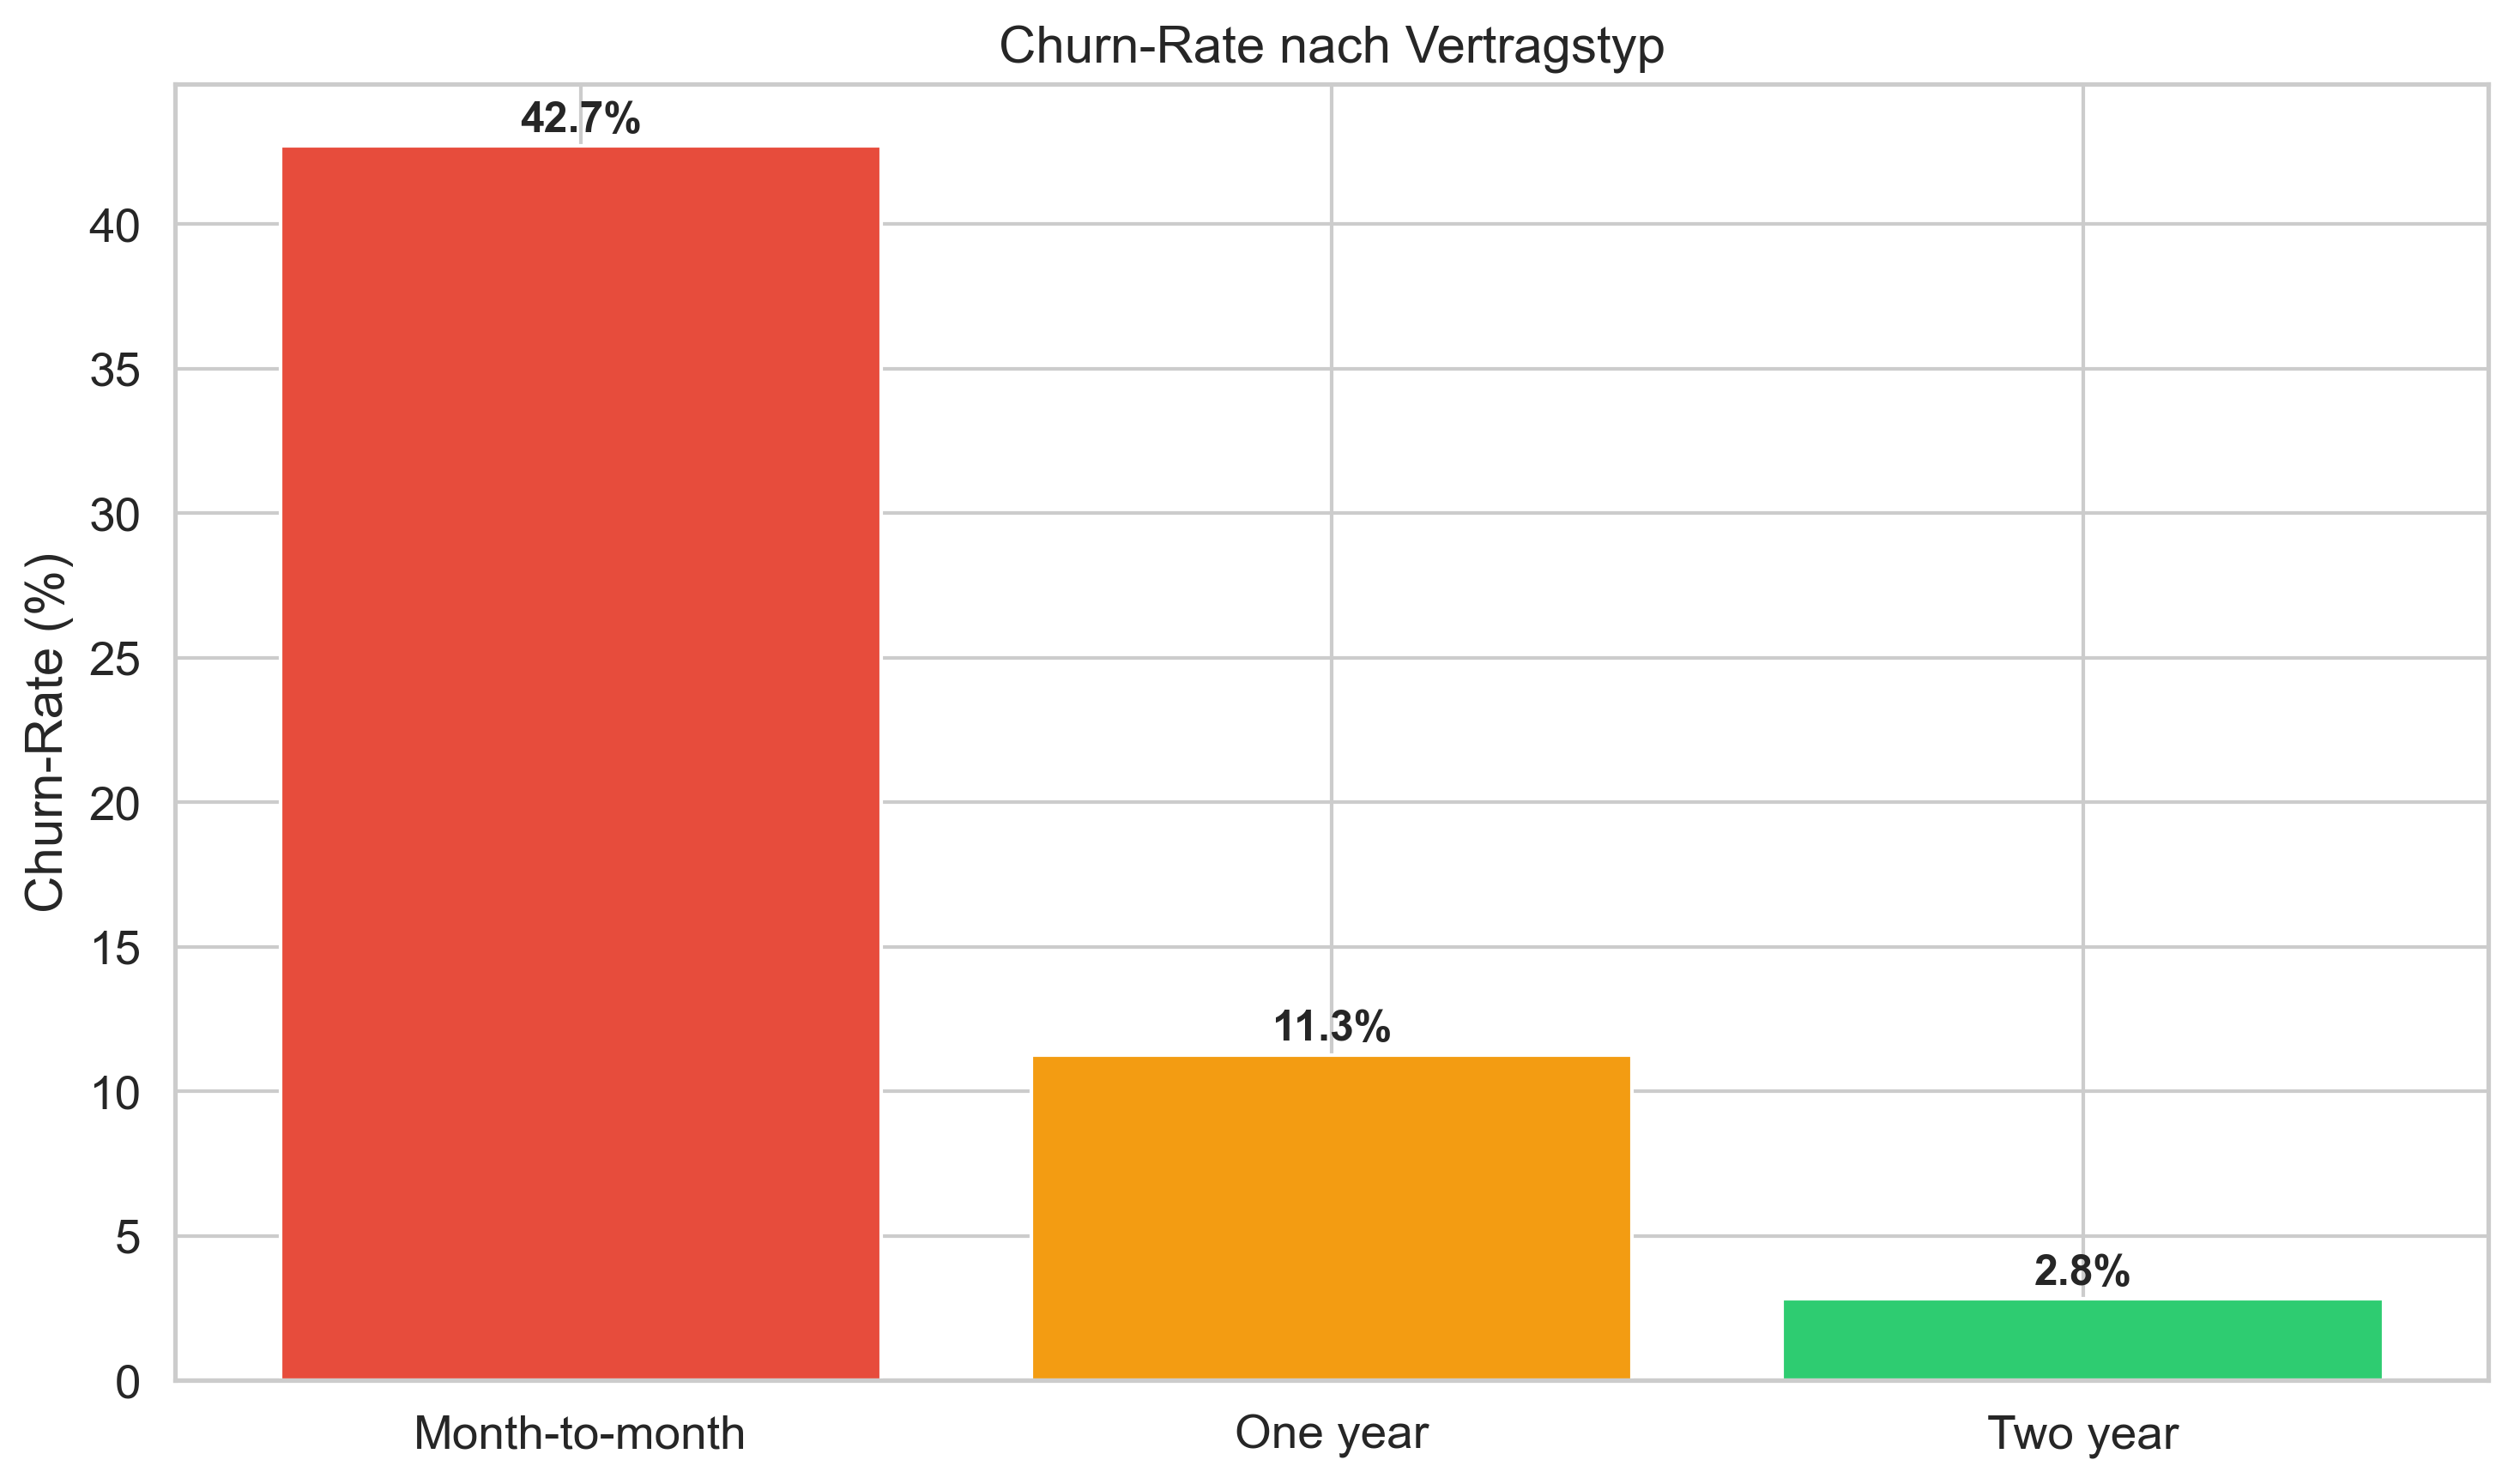

In [ ]:
# --- Churn nach Vertragstyp ---
cr_contract = churn_rate_by(df, "Contract")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cr_contract.index, cr_contract.values * 100, color=["#e74c3c", "#f39c12", "#2ecc71"])
for bar, val in zip(bars, cr_contract.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold",
    )
ax.set_ylabel("Churn-Rate (%)")
ax.set_title("Churn-Rate nach Vertragstyp")
plt.tight_layout()
fig.savefig("plots/02_churn_nach_contract.png")
plt.show()

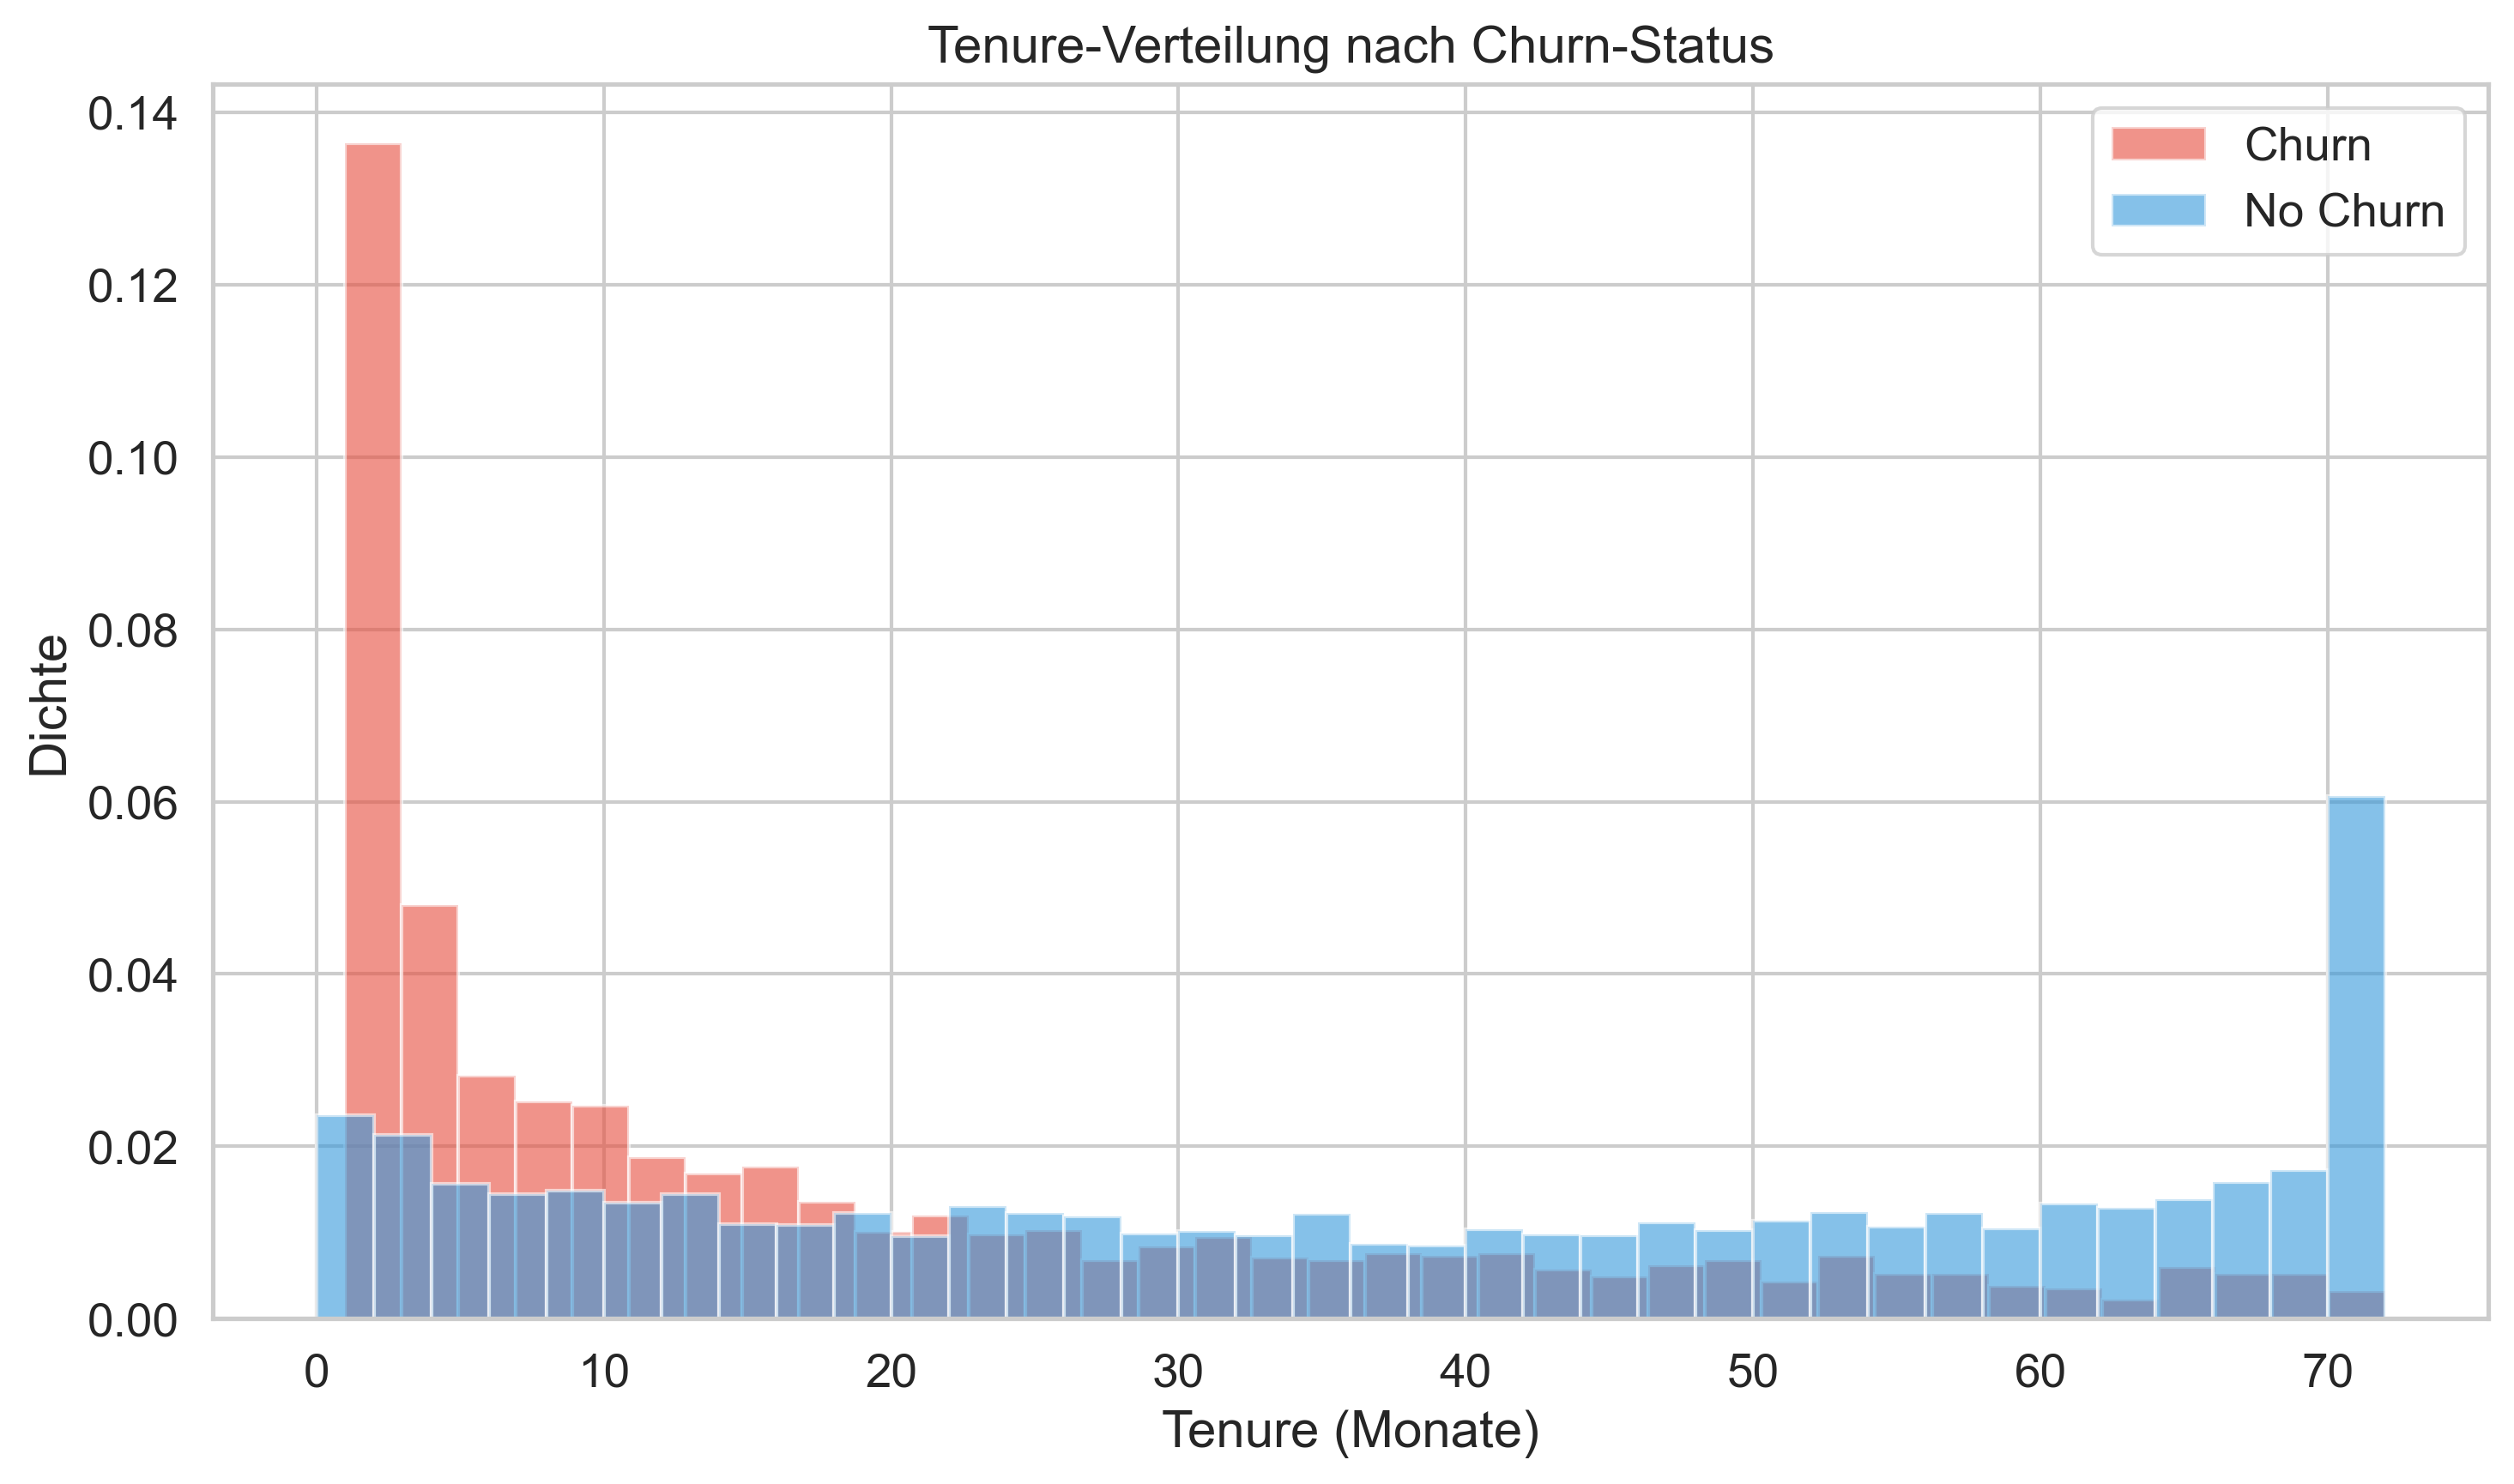

In [ ]:
# --- Churn nach Tenure (Density-Plot) ---
fig, ax = plt.subplots(figsize=(10, 6))
for label, color in CHURN_COLORS_01.items():
    subset = df[df["Churn"] == label]
    ax.hist(
        subset["tenure"], bins=36, alpha=0.6,
        label=f"{'Churn' if label == 1 else 'No Churn'}",
        color=color, density=True,
    )
ax.set_xlabel("Tenure (Monate)")
ax.set_ylabel("Dichte")
ax.set_title("Tenure-Verteilung nach Churn-Status")
ax.legend()
plt.tight_layout()
fig.savefig("plots/03_churn_nach_tenure.png")
plt.show()

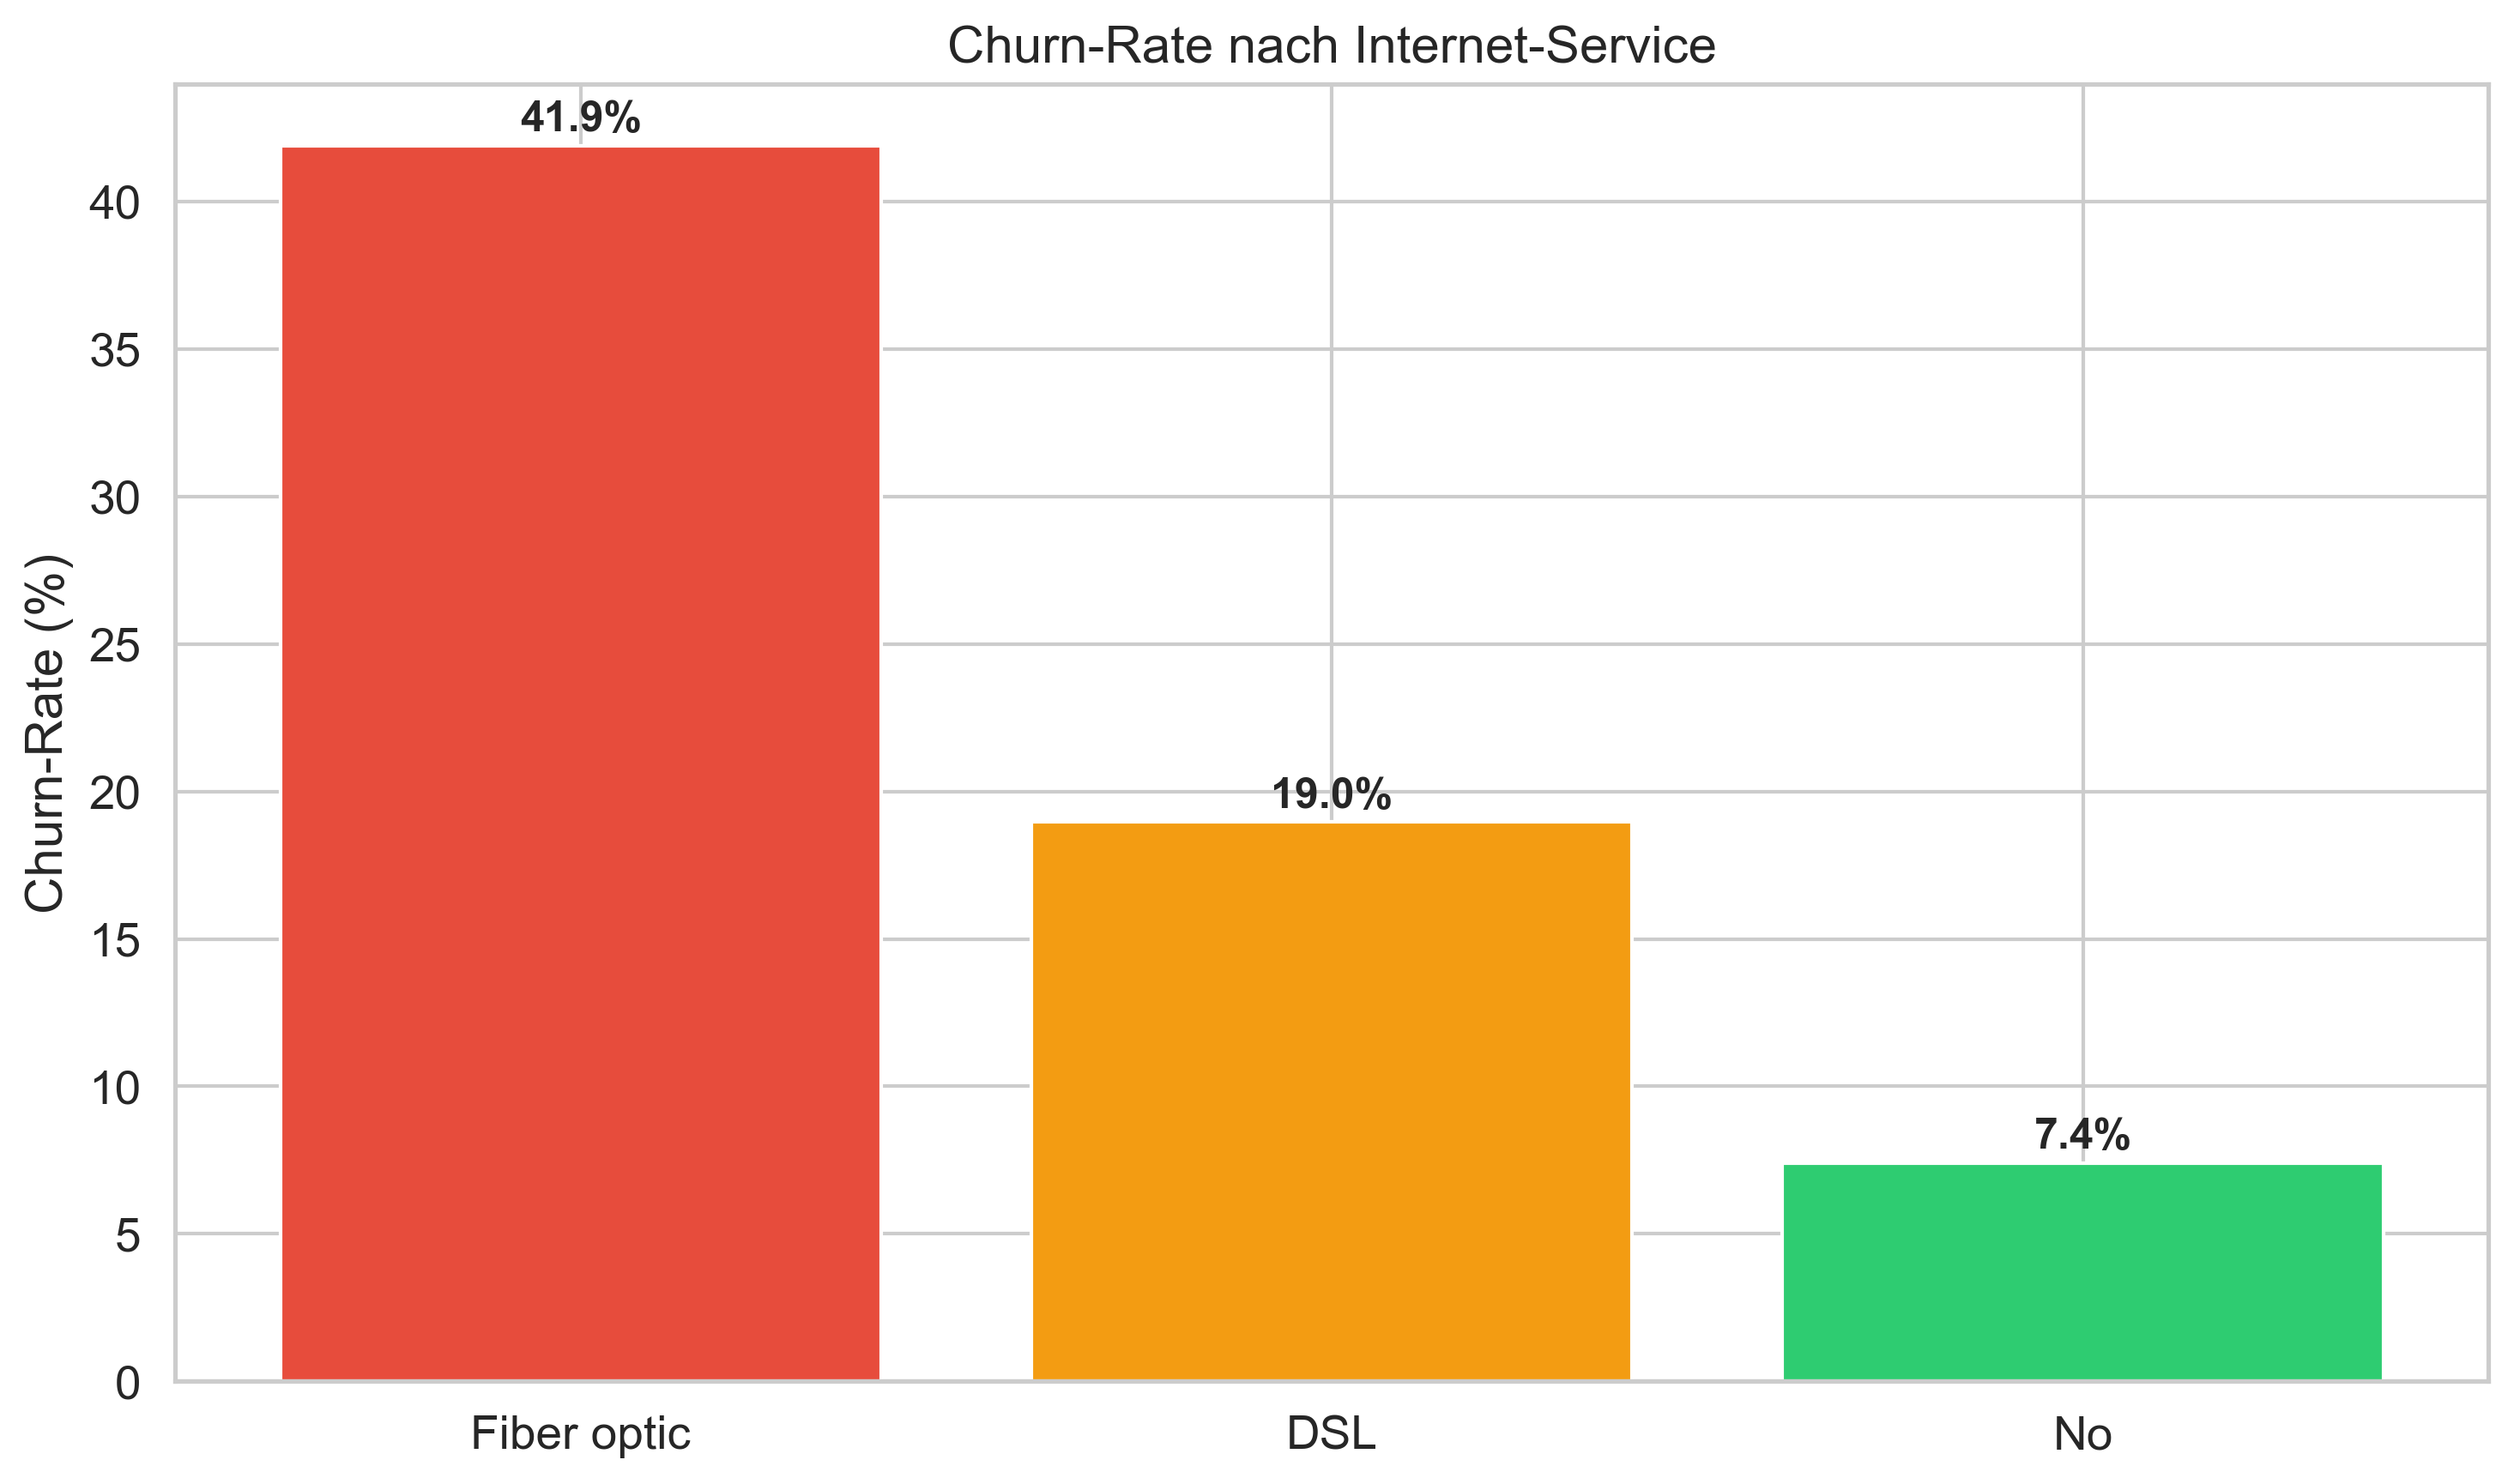

In [ ]:
# --- Churn nach Internet-Service ---
cr_internet = churn_rate_by(df, "InternetService")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cr_internet.index, cr_internet.values * 100, color=["#e74c3c", "#f39c12", "#2ecc71"])
for bar, val in zip(bars, cr_internet.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold",
    )
ax.set_ylabel("Churn-Rate (%)")
ax.set_title("Churn-Rate nach Internet-Service")
plt.tight_layout()
fig.savefig("plots/04_churn_nach_internetservice.png")
plt.show()

### 2.3 Churn nach allen anderen Merkmalen

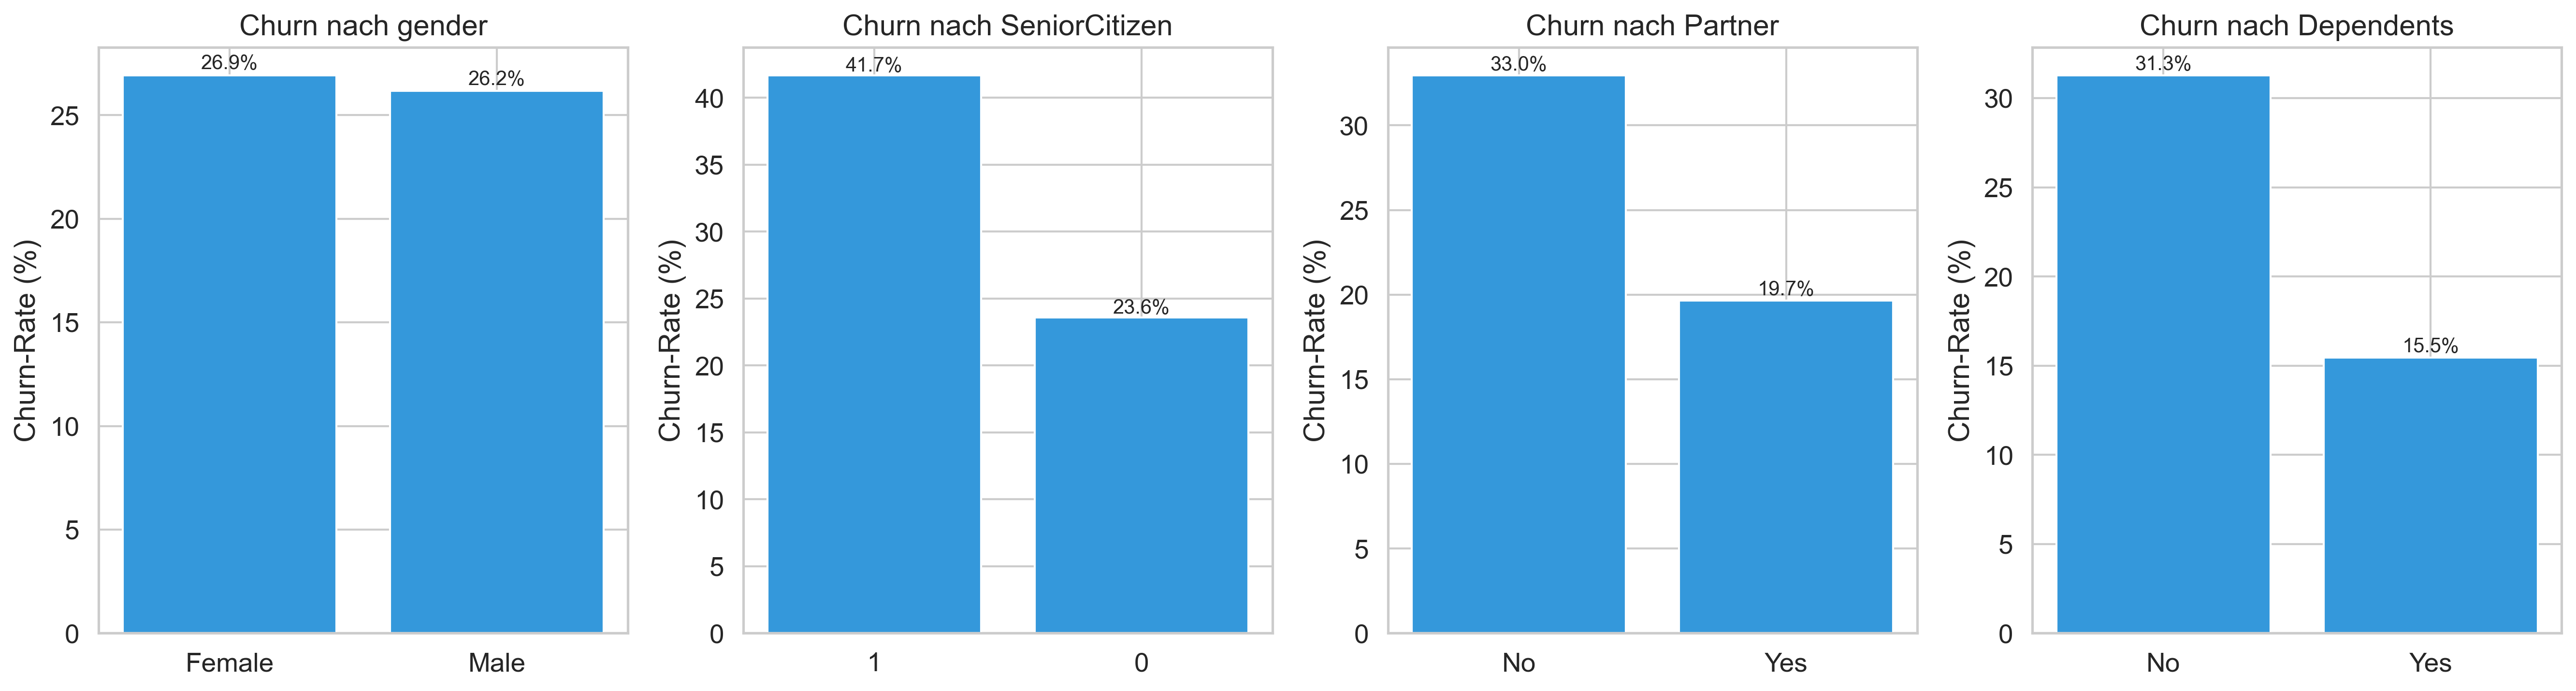

In [ ]:
# --- Demografische Merkmale ---
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, demo_cols):
    cr = churn_rate_by(df, col) * 100
    bars = ax.bar(cr.index.astype(str), cr.values, color="#3498db")
    for bar, val in zip(bars, cr.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10,
        )
    ax.set_title(f"Churn nach {col}")
    ax.set_ylabel("Churn-Rate (%)")
plt.tight_layout()
fig.savefig("plots/05_churn_nach_demografie.png")
plt.show()

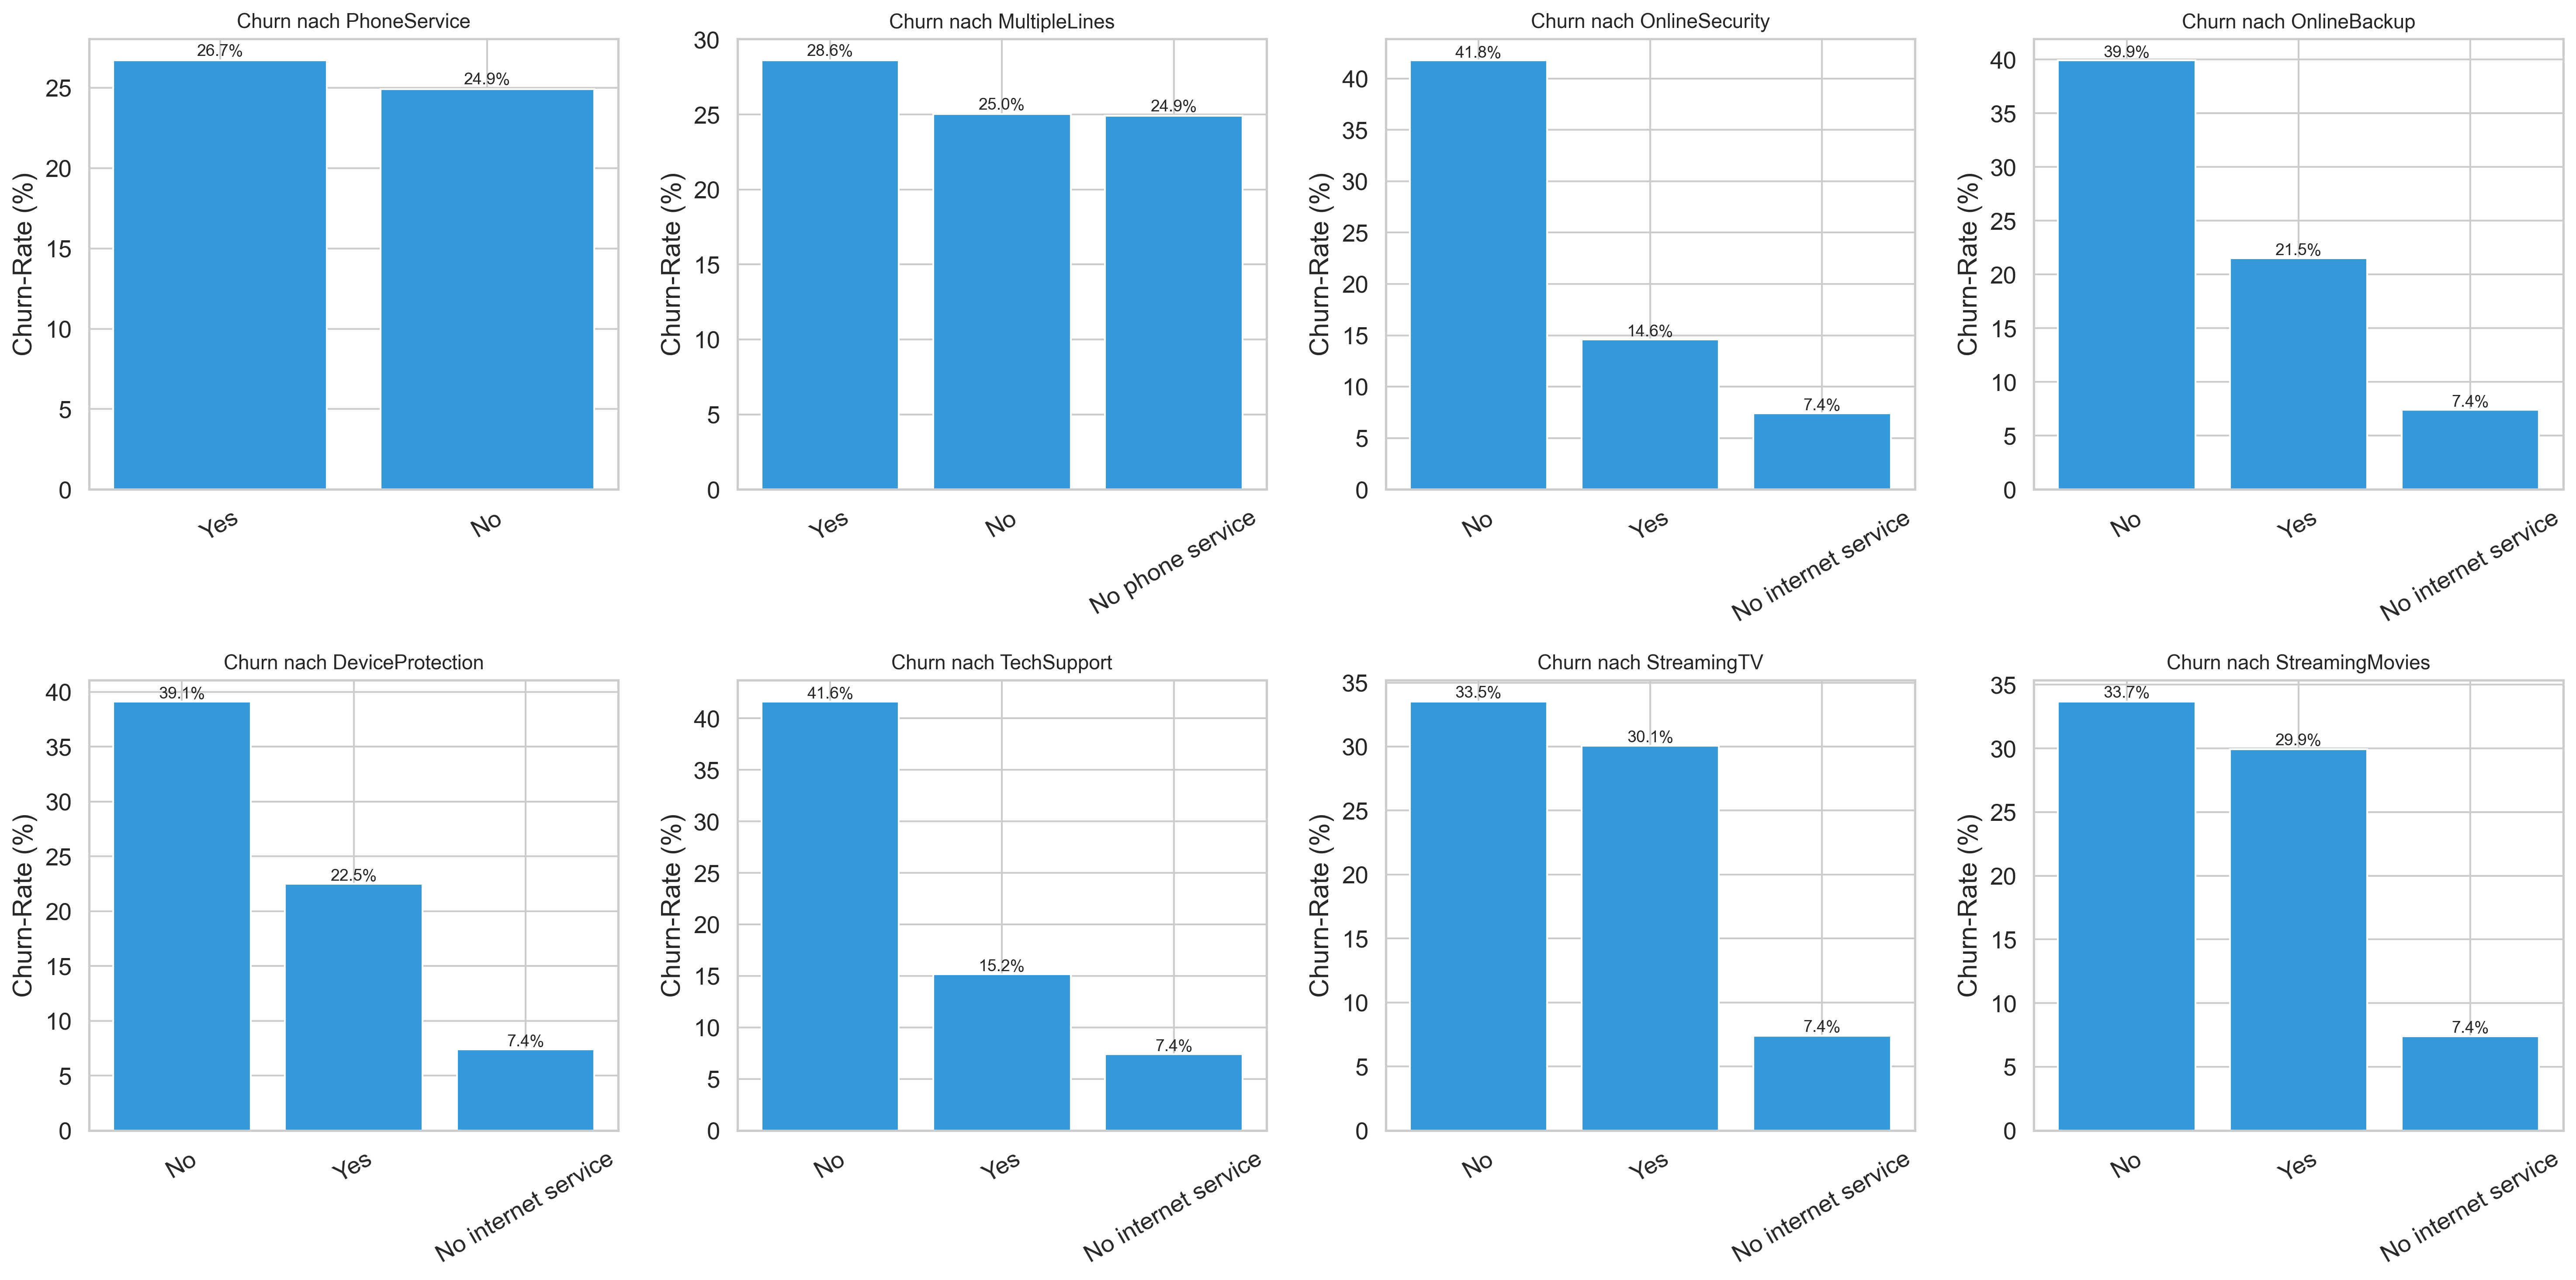

In [ ]:
# --- Produkt-Features ---
service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.flatten(), service_cols):
    cr = churn_rate_by(df, col) * 100
    bars = ax.bar(cr.index.astype(str), cr.values, color="#3498db")
    for bar, val in zip(bars, cr.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=9,
        )
    ax.set_title(f"Churn nach {col}", fontsize=11)
    ax.set_ylabel("Churn-Rate (%)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
fig.savefig("plots/06_churn_nach_services.png")
plt.show()

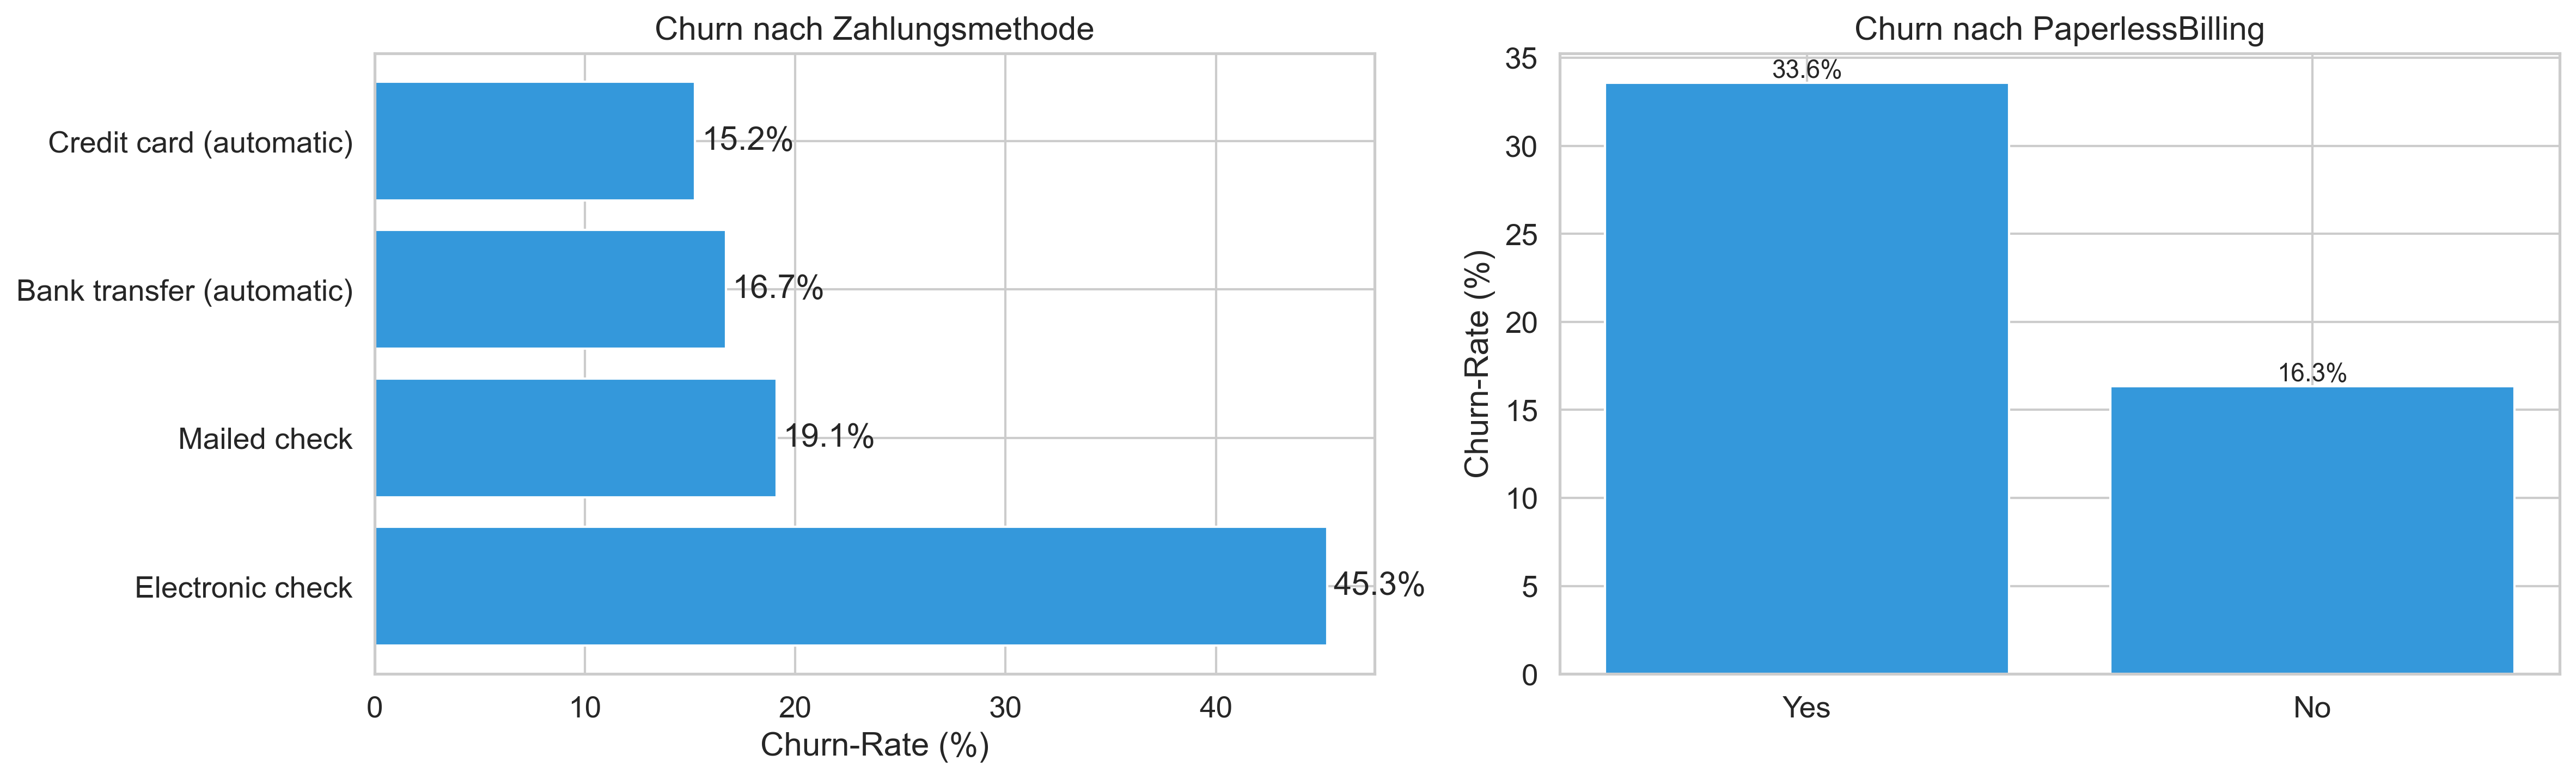

In [ ]:
# --- PaymentMethod & PaperlessBilling ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cr_pay = churn_rate_by(df, "PaymentMethod") * 100
bars = axes[0].barh(cr_pay.index, cr_pay.values, color="#3498db")
for bar, val in zip(bars, cr_pay.values):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center")
axes[0].set_xlabel("Churn-Rate (%)")
axes[0].set_title("Churn nach Zahlungsmethode")

cr_paper = churn_rate_by(df, "PaperlessBilling") * 100
bars = axes[1].bar(cr_paper.index.astype(str), cr_paper.values, color="#3498db")
for bar, val in zip(bars, cr_paper.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{val:.1f}%", ha="center", fontsize=11,
    )
axes[1].set_ylabel("Churn-Rate (%)")
axes[1].set_title("Churn nach PaperlessBilling")

plt.tight_layout()
fig.savefig("plots/07_churn_nach_payment_billing.png")
plt.show()

C:\Users\heier\AppData\Local\Temp\ipykernel_21064\2539206402.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=churn_labels, y=df["MonthlyCharges"], palette=boxplot_palette, ax=axes[0])
C:\Users\heier\AppData\Local\Temp\ipykernel_21064\2539206402.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=churn_labels, y=df["TotalCharges"], palette=boxplot_palette, ax=axes[1])


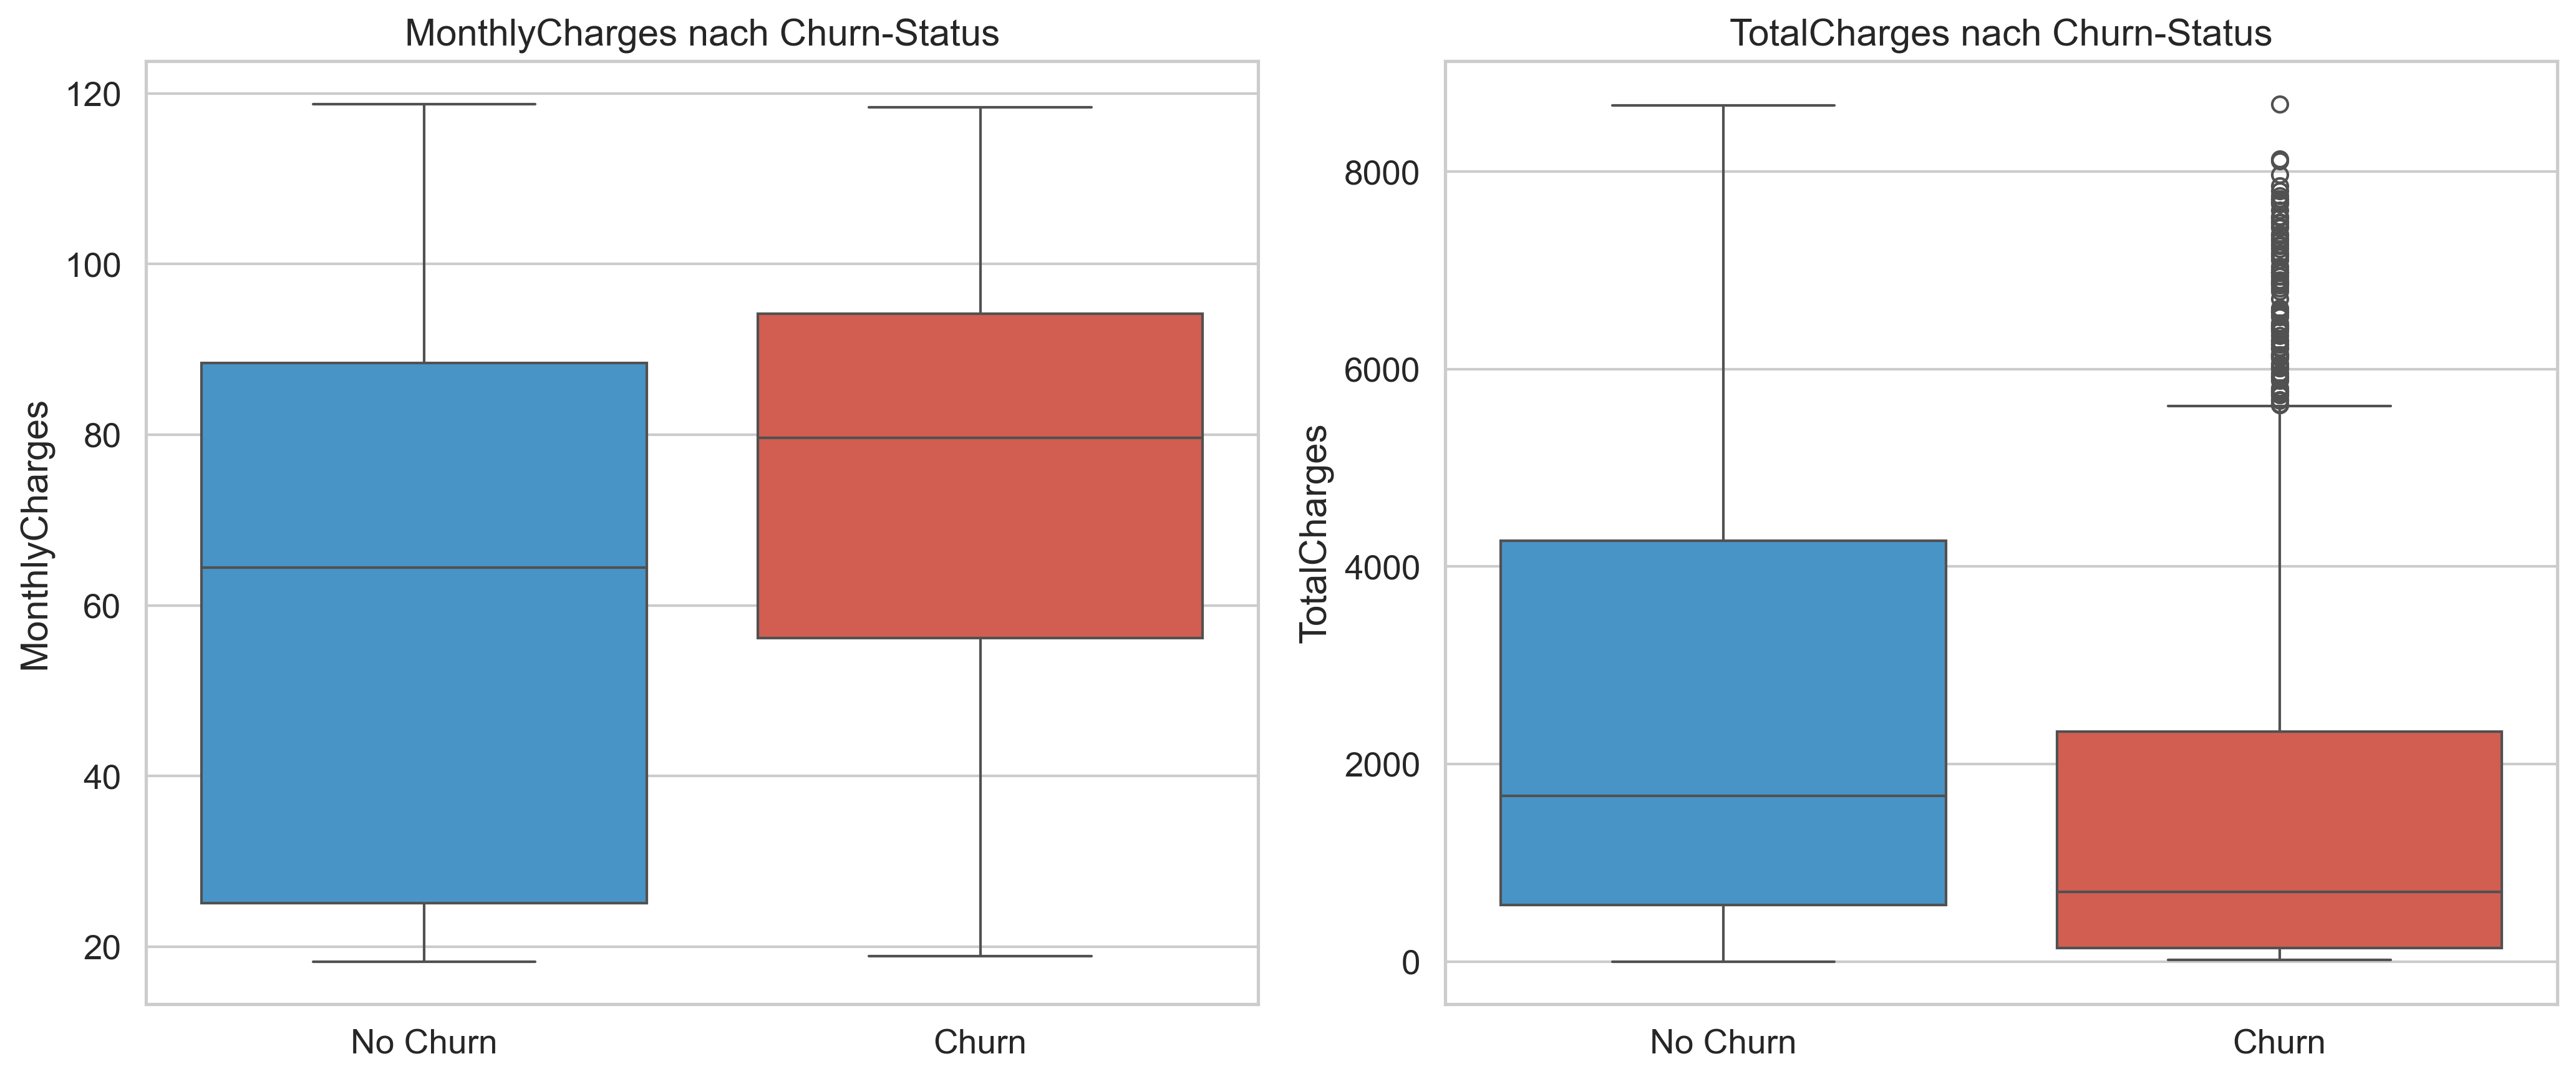

In [ ]:
# --- Box-Plots: MonthlyCharges & TotalCharges ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

churn_labels = df["Churn"].map({0: "No Churn", 1: "Churn"})
boxplot_palette = {"No Churn": "#3498db", "Churn": "#e74c3c"}

sns.boxplot(x=churn_labels, y=df["MonthlyCharges"], palette=boxplot_palette, ax=axes[0])
axes[0].set_title("MonthlyCharges nach Churn-Status")
axes[0].set_xlabel("")

sns.boxplot(x=churn_labels, y=df["TotalCharges"], palette=boxplot_palette, ax=axes[1])
axes[1].set_title("TotalCharges nach Churn-Status")
axes[1].set_xlabel("")

plt.tight_layout()
fig.savefig("plots/08_boxplots_charges.png")
plt.show()

### 2.4 Korrelationsanalyse

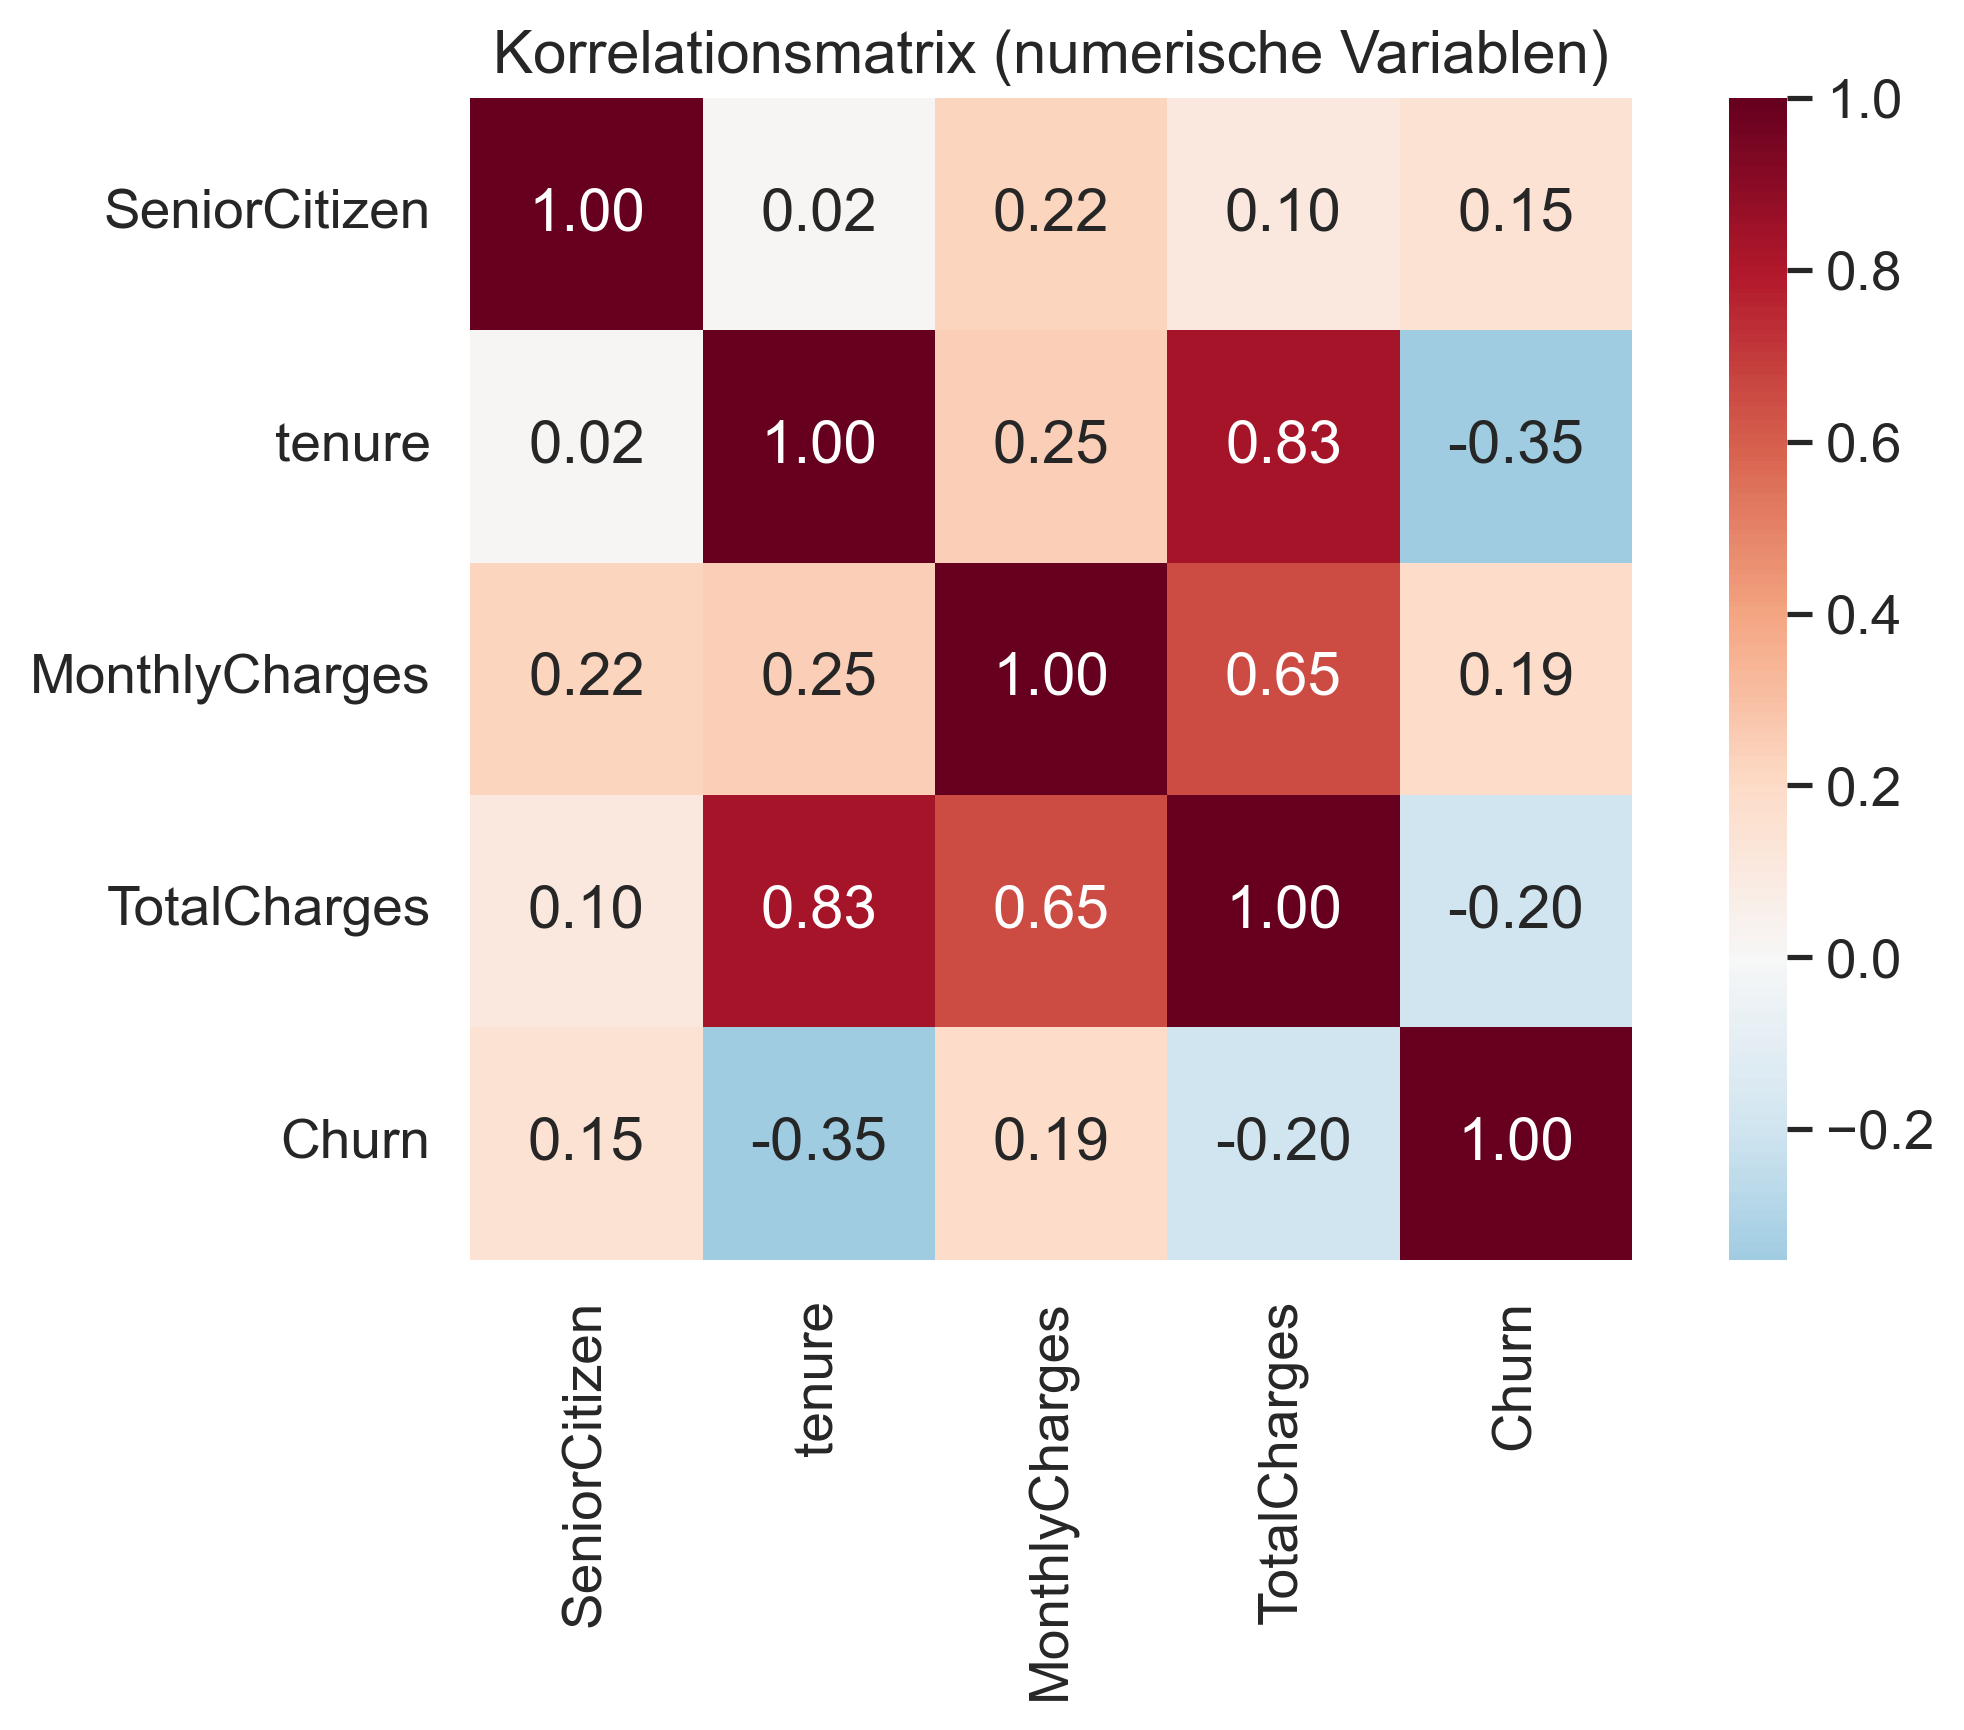

In [ ]:
# Numerische Korrelationsmatrix
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, square=True, ax=ax,
)
ax.set_title("Korrelationsmatrix (numerische Variablen)")
plt.tight_layout()
fig.savefig("plots/09_korrelationsmatrix.png")
plt.show()

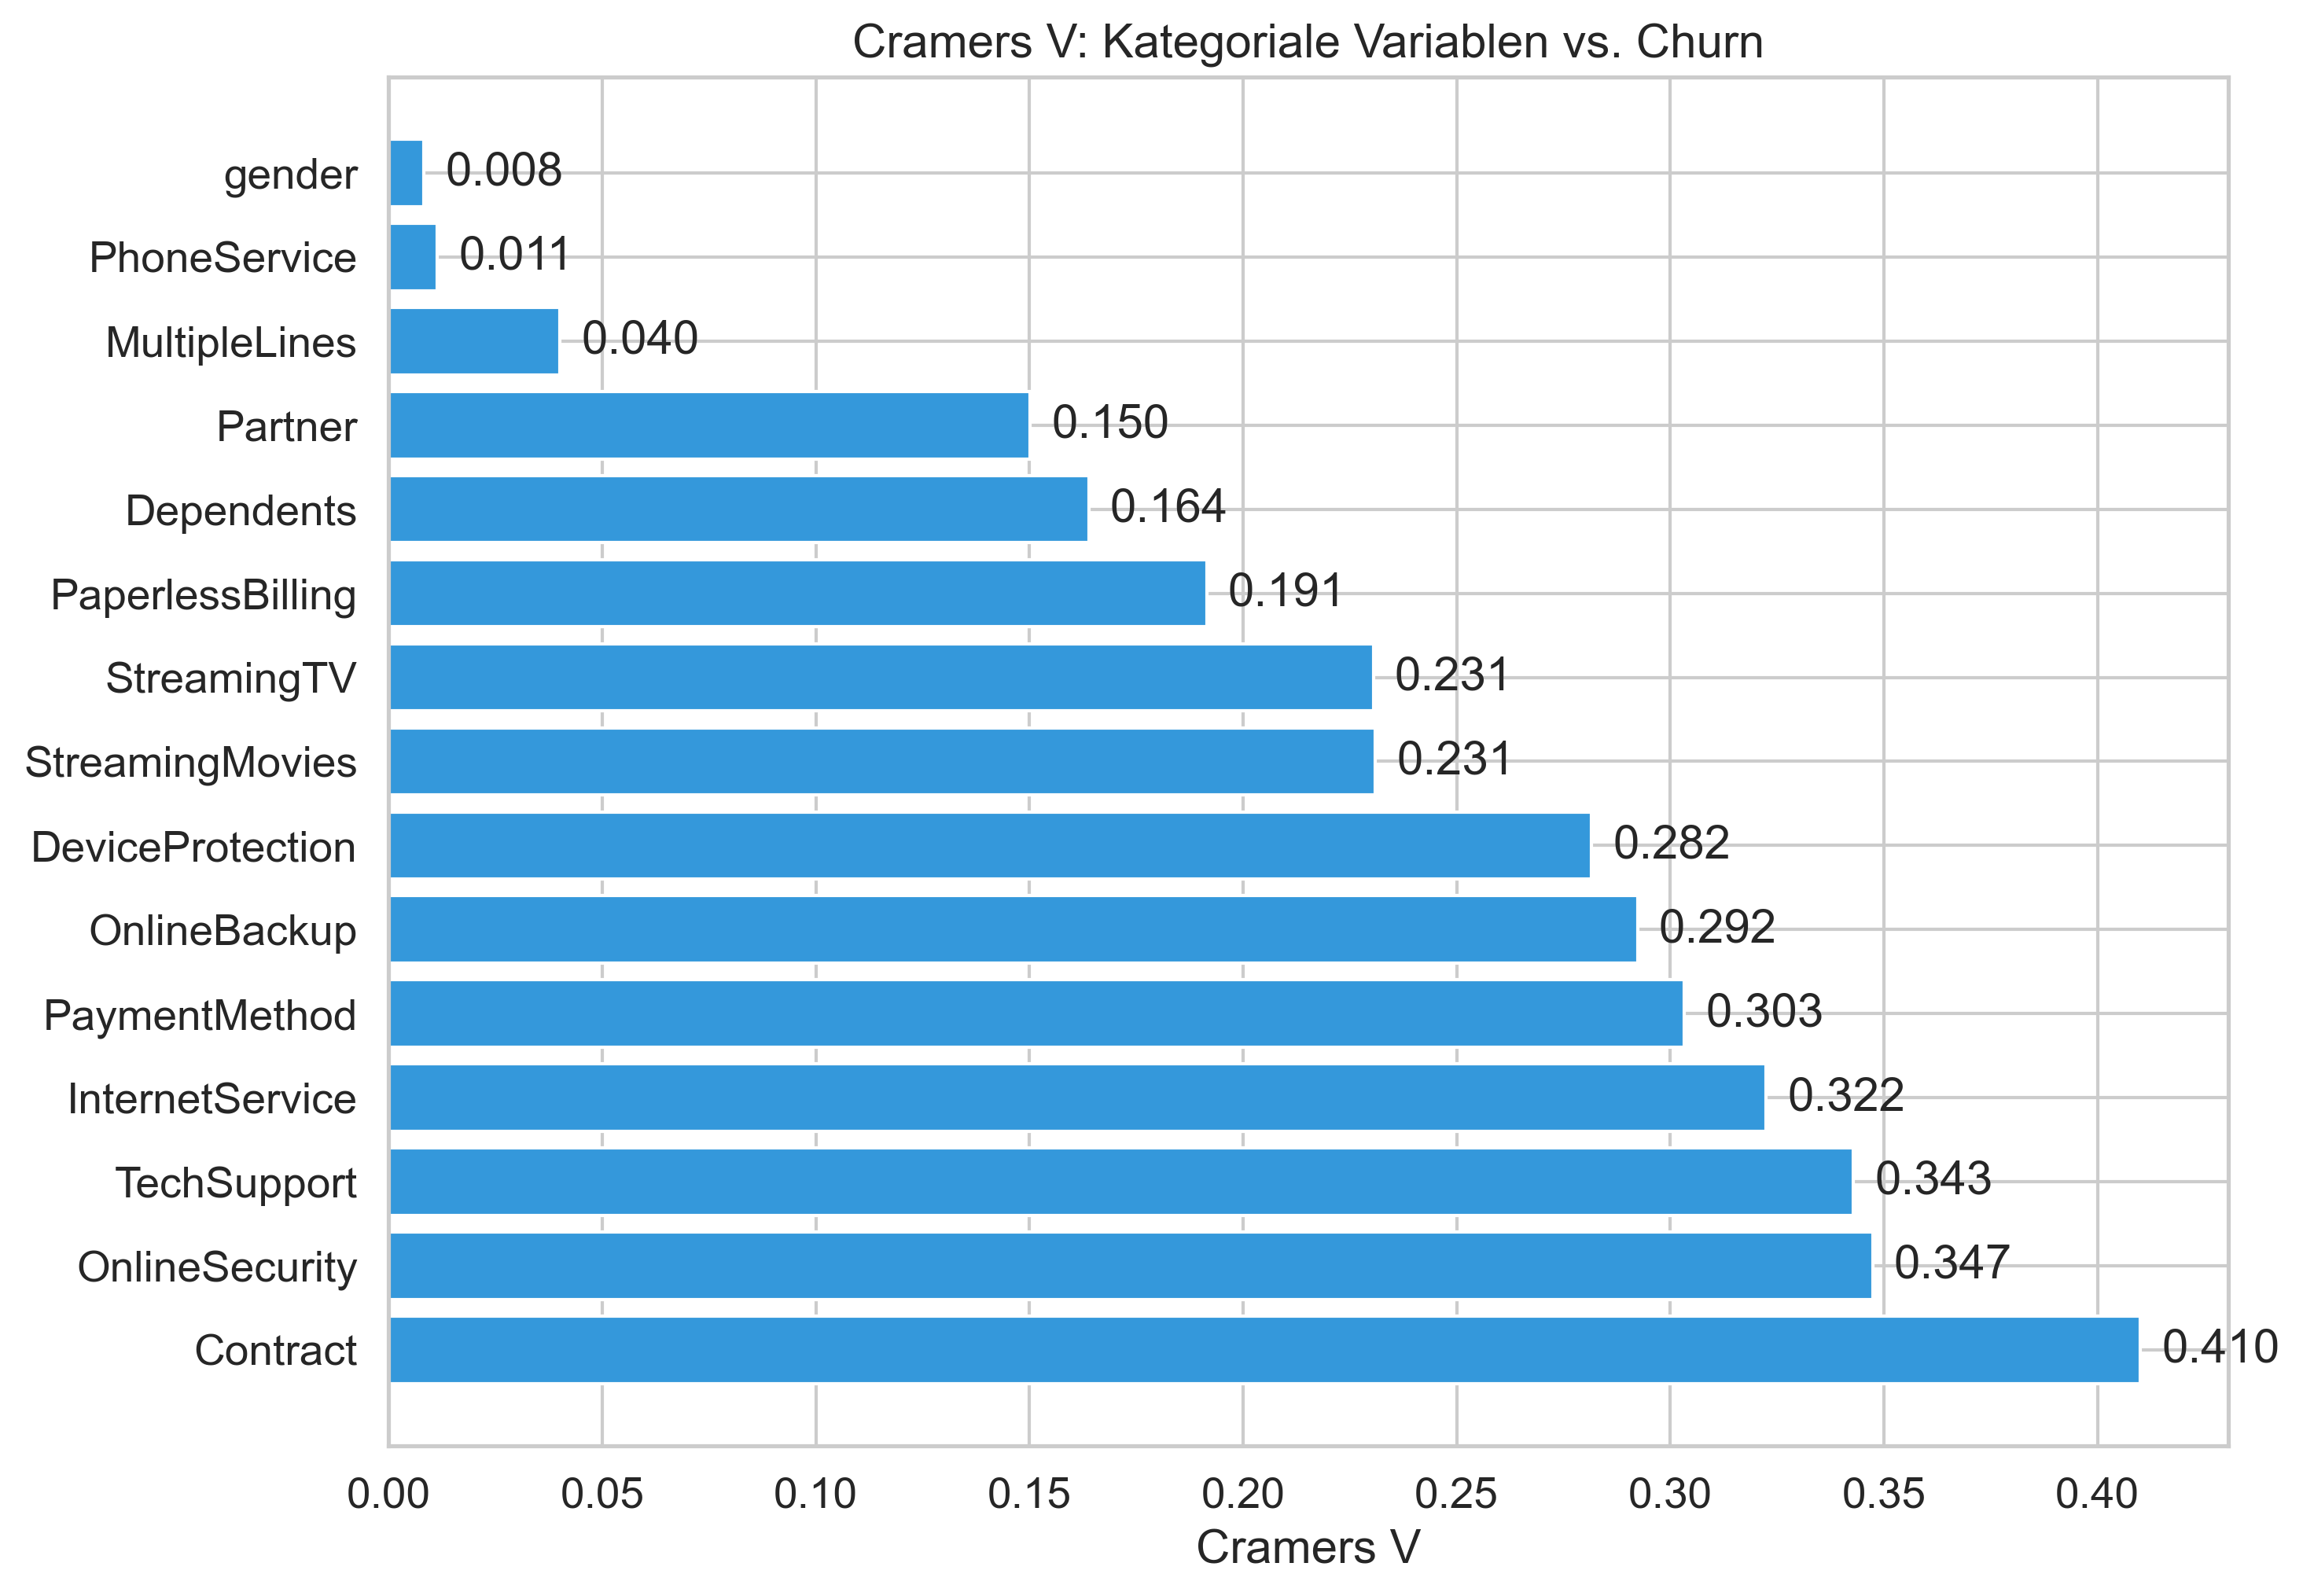

In [ ]:
# Cramers V fuer kategoriale Variablen vs. Churn
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod",
]

cramers = {col: cramers_v(df[col], df["Churn"]) for col in cat_cols}
cramers_df = pd.Series(cramers).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cramers_df.index, cramers_df.values, color="#3498db")
ax.set_xlabel("Cramers V")
ax.set_title("Cramers V: Kategoriale Variablen vs. Churn")
for i, val in enumerate(cramers_df.values):
    ax.text(val + 0.005, i, f"{val:.3f}", va="center")
plt.tight_layout()
fig.savefig("plots/10_cramers_v.png")
plt.show()

### 2.5 Tenure-Tiefenanalyse

In [ ]:
# Tenure-Gruppen erstellen
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

cr_tenure = df.groupby("tenure_group")["Churn"].agg(["mean", "count"])
cr_tenure.columns = ["Churn-Rate", "Anzahl"]
cr_tenure["Churn-Rate %"] = (cr_tenure["Churn-Rate"] * 100).round(1)
print(cr_tenure)

              Churn-Rate  Anzahl  Churn-Rate %
tenure_group                                  
0-12            0.474382    2186          47.4
13-24           0.287109    1024          28.7
25-48           0.203890    1594          20.4
49-72           0.095132    2239           9.5


C:\Users\heier\AppData\Local\Temp\ipykernel_21064\3415935487.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cr_tenure = df.groupby("tenure_group")["Churn"].agg(["mean", "count"])


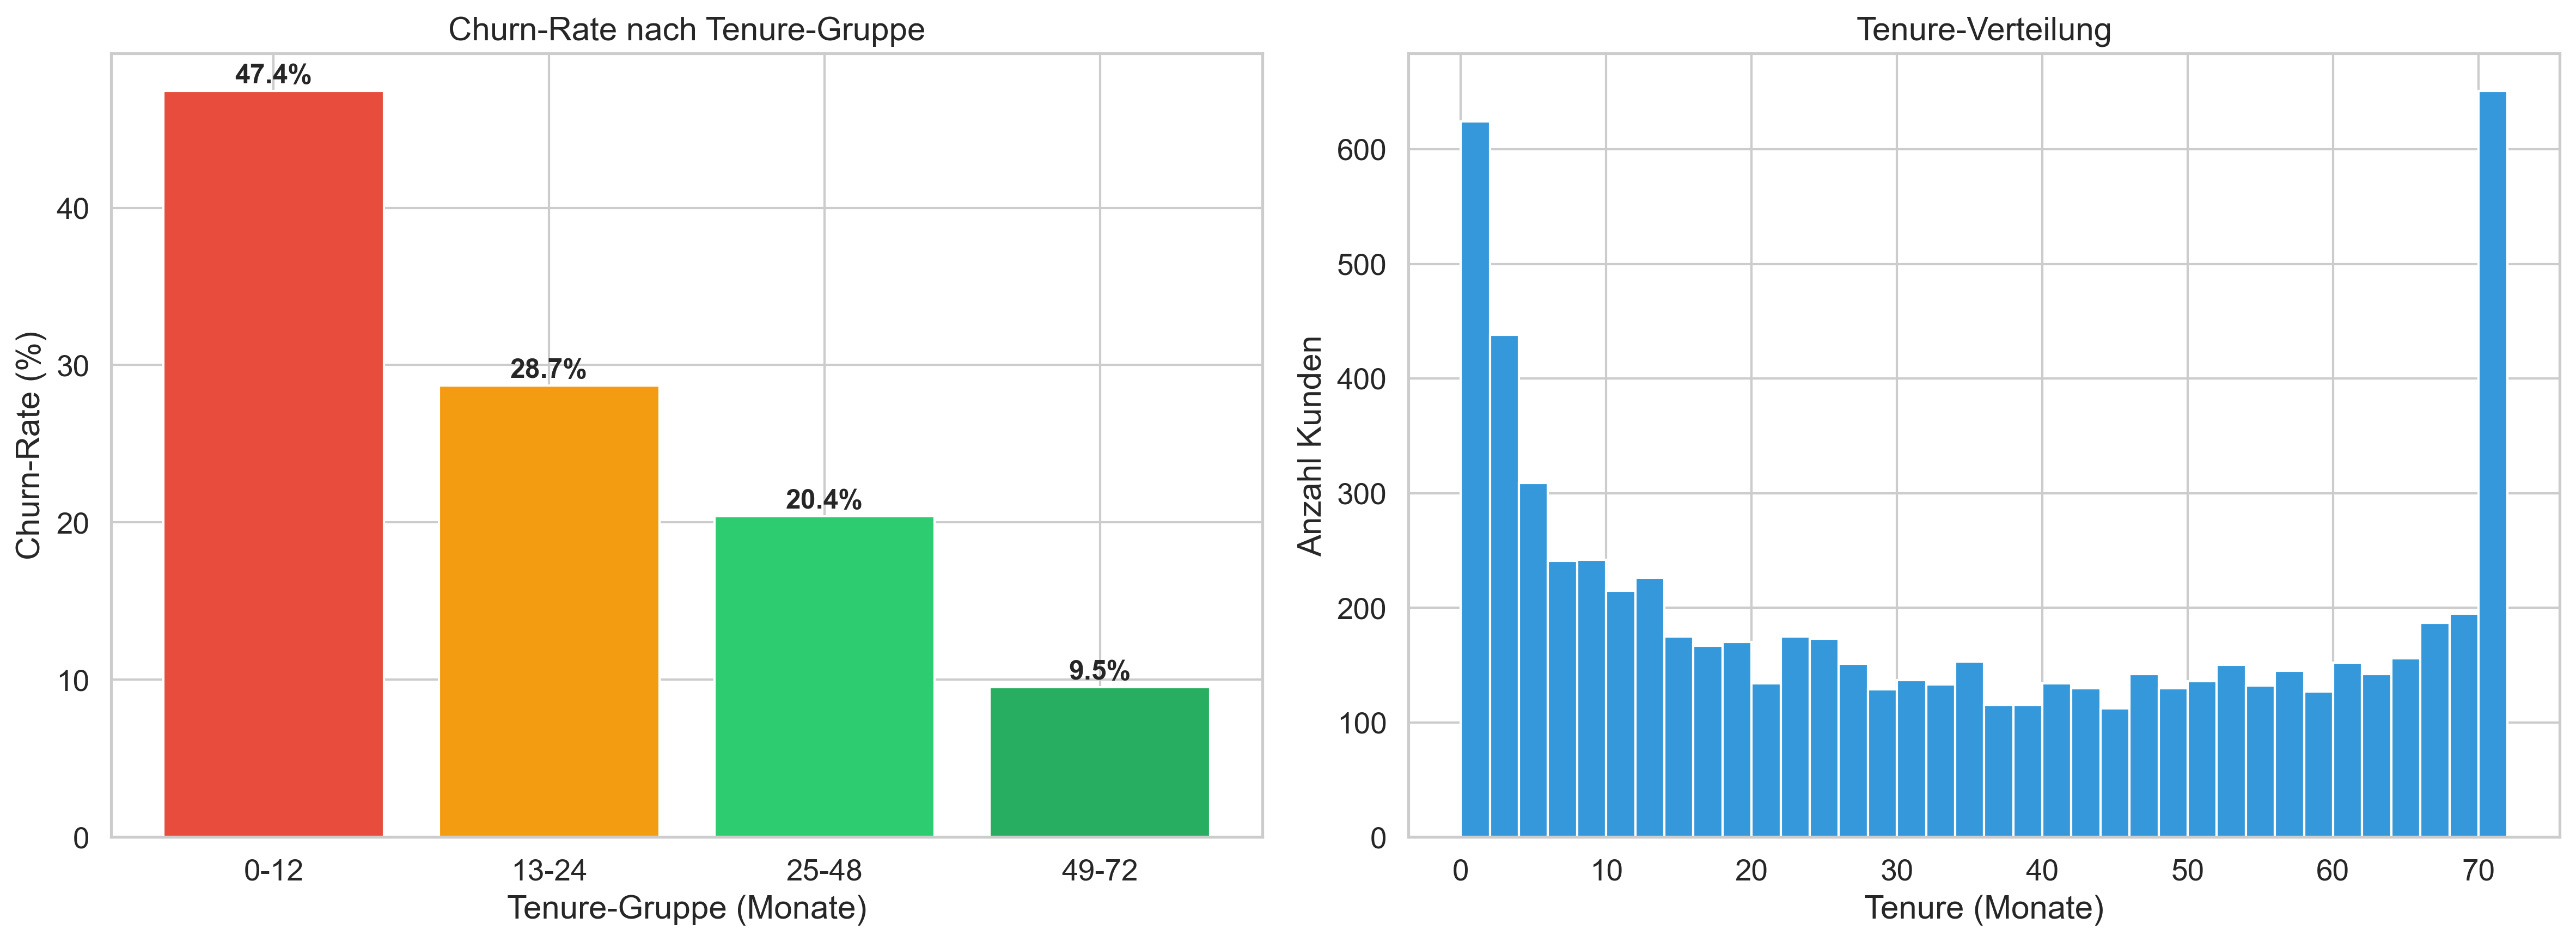

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Churn-Rate pro Tenure-Gruppe
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#27ae60"]
bars = axes[0].bar(cr_tenure.index.astype(str), cr_tenure["Churn-Rate"] * 100, color=colors)
for bar, val in zip(bars, cr_tenure["Churn-Rate"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold",
    )
axes[0].set_xlabel("Tenure-Gruppe (Monate)")
axes[0].set_ylabel("Churn-Rate (%)")
axes[0].set_title("Churn-Rate nach Tenure-Gruppe")

# Tenure-Verteilung insgesamt
axes[1].hist(df["tenure"], bins=36, color="#3498db", edgecolor="white")
axes[1].set_xlabel("Tenure (Monate)")
axes[1].set_ylabel("Anzahl Kunden")
axes[1].set_title("Tenure-Verteilung")

plt.tight_layout()
fig.savefig("plots/11_tenure_tiefenanalyse.png")
plt.show()

---
## Zusammenfassung EDA

Hier die wichtigsten Erkenntnisse dokumentieren nach Ausfuehrung:
- Churn-Rate: ~26.5% (Class Imbalance)
- Staerkste Treiber: Vertragstyp (Month-to-month), Tenure (kurz), InternetService (Fiber optic)
- Fiber-optic-Kunden churnen deutlich haeufiger als DSL
- Kunden ohne TechSupport/OnlineSecurity churnen haeufiger
- Electronic Check als Zahlungsmethode korreliert mit hoeherer Churn-Rate